In [1]:
# !pip install pyreadr
# !pip install matplotlib
# !pip install seaborn
# !pip install scipy
# !pip install scikit-learn
# !pip install adjustText

In [2]:
import pyreadr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D     

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

from scipy.stats import gaussian_kde


### Setup - Common Definitions
Run this cell once after loading the data.

In [3]:
result = pyreadr.read_r('./pisa2018.Rdata') # also works for Rds
print(result.keys()) # let's check what objects we got

odict_keys(['newdata'])


In [4]:
# ============================================================================
# SETUP CELL - Common Definitions for All Plots
# Run this cell AFTER loading the data
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Subjects
SUBJECTS = ['MATH', 'READ', 'SCIE', 'GLCM']
SUBJECT_NAMES = ['Mathematics', 'Reading', 'Science', 'Global Competence']
CONTINENTS = ['Europe', 'Asia', 'Americas', 'Oceania', 'Africa']

# ============================================================================
# CONTINENT MAPPING (broad geographic grouping)
# ============================================================================

CONTINENT_MAPPING = {
    # Europe
    'Albania': 'Europe', 'Austria': 'Europe', 'Belgium': 'Europe', 'Bosnia and Herzegovina': 'Europe',
    'Bulgaria': 'Europe', 'Croatia': 'Europe', 'Cyprus': 'Europe', 'Czech Republic': 'Europe',
    'Denmark': 'Europe', 'Estonia': 'Europe', 'Finland': 'Europe', 'France': 'Europe',
    'Germany': 'Europe', 'Greece': 'Europe', 'Hungary': 'Europe', 'Iceland': 'Europe',
    'Ireland': 'Europe', 'Italy': 'Europe', 'Latvia': 'Europe', 'Lithuania': 'Europe',
    'Luxembourg': 'Europe', 'Malta': 'Europe', 'Netherlands': 'Europe', 'Norway': 'Europe',
    'Poland': 'Europe', 'Portugal': 'Europe', 'Romania': 'Europe', 'Russia': 'Europe',
    'Serbia': 'Europe', 'Slovakia': 'Europe', 'Slovenia': 'Europe', 'Spain': 'Europe',
    'Sweden': 'Europe', 'Switzerland': 'Europe', 'Turkey': 'Europe', 'Ukraine': 'Europe',
    'United Kingdom': 'Europe', 'Belarus': 'Europe', 'North Macedonia': 'Europe',
    'Montenegro': 'Europe',
    
    # Asia
    'Azerbaijan': 'Asia', 'Brunei Darussalam': 'Asia', 'China': 'Asia', 'B-S-J-Z (China)': 'Asia',
    'Georgia': 'Asia', 'Hong Kong': 'Asia', 'Indonesia': 'Asia', 'Israel': 'Asia',
    'Japan': 'Asia', 'Jordan': 'Asia', 'Kazakhstan': 'Asia', 'Korea': 'Asia',
    'Kyrgyzstan': 'Asia', 'Lebanon': 'Asia', 'Macao': 'Asia', 'Malaysia': 'Asia',
    'Philippines': 'Asia', 'Qatar': 'Asia', 'Saudi Arabia': 'Asia', 'Singapore': 'Asia',
    'Taiwan': 'Asia', 'Thailand': 'Asia', 'United Arab Emirates': 'Asia', 'Vietnam': 'Asia',
    'Uzbekistan': 'Asia',
    
    # Americas
    'Argentina': 'Americas', 'Brazil': 'Americas', 'Canada': 'Americas', 'Chile': 'Americas',
    'Colombia': 'Americas', 'Costa Rica': 'Americas', 'Dominican Republic': 'Americas',
    'Mexico': 'Americas', 'Panama': 'Americas', 'Peru': 'Americas', 'United States': 'Americas',
    'Uruguay': 'Americas',
    
    # Oceania
    'Australia': 'Oceania', 'New Zealand': 'Oceania',
    
    # Africa
    'Morocco': 'Africa', 'Tunisia': 'Africa',
}

CONTINENT_COLORS = {
    'Europe': '#5A7A9E',
    'Asia': '#F39C12',
    'Americas': '#78909C',
    'Oceania': '#00BCD4',
    'Africa': '#95A5A6',
    'Greece': '#B71C1C',  # Special color for Greece
}

# ============================================================================
# REGION DEFINITIONS (for detailed regional analysis)
# ============================================================================

REGION_MAPPING = {
    # Mediterranean
    'Greece': 'Mediterranean', 'Italy': 'Mediterranean', 'Spain': 'Mediterranean',
    'Portugal': 'Mediterranean', 'Croatia': 'Mediterranean', 'Albania': 'Mediterranean',
    'Turkey': 'Mediterranean', 'Cyprus': 'Mediterranean', 'Malta': 'Mediterranean',
    'North Macedonia': 'Mediterranean', 'Montenegro': 'Mediterranean',
    'Bosnia and Herzegovina': 'Mediterranean',
    
    # Northern Europe
    'Finland': 'Northern Europe', 'Sweden': 'Northern Europe', 'Norway': 'Northern Europe',
    'Denmark': 'Northern Europe', 'Iceland': 'Northern Europe', 'Estonia': 'Northern Europe',
    'Latvia': 'Northern Europe', 'Lithuania': 'Northern Europe',
    
    # Western Europe
    'Germany': 'Western Europe', 'France': 'Western Europe', 'Netherlands': 'Western Europe',
    'Belgium': 'Western Europe', 'Austria': 'Western Europe', 'Switzerland': 'Western Europe',
    'Luxembourg': 'Western Europe', 'Ireland': 'Western Europe', 'United Kingdom': 'Western Europe',
    
    # Eastern Europe
    'Poland': 'Eastern Europe', 'Czech Republic': 'Eastern Europe', 'Slovakia': 'Eastern Europe',
    'Hungary': 'Eastern Europe', 'Romania': 'Eastern Europe', 'Bulgaria': 'Eastern Europe',
    'Slovenia': 'Eastern Europe', 'Serbia': 'Eastern Europe', 'Russia': 'Eastern Europe',
    'Ukraine': 'Eastern Europe', 'Belarus': 'Eastern Europe',
    
    # East Asia
    'China': 'East Asia', 'B-S-J-Z (China)': 'East Asia', 'Japan': 'East Asia',
    'Korea': 'East Asia', 'Singapore': 'East Asia', 'Hong Kong': 'East Asia',
    'Taiwan': 'East Asia', 'Macao': 'East Asia',
    
    # Southeast Asia
    'Thailand': 'Southeast Asia', 'Vietnam': 'Southeast Asia', 'Indonesia': 'Southeast Asia',
    'Philippines': 'Southeast Asia', 'Malaysia': 'Southeast Asia',
    'Brunei Darussalam': 'Southeast Asia',
    
    # Middle East
    'Israel': 'Middle East', 'United Arab Emirates': 'Middle East', 'Qatar': 'Middle East',
    'Saudi Arabia': 'Middle East', 'Jordan': 'Middle East', 'Lebanon': 'Middle East',
    'Morocco': 'Middle East',
    
    # Americas
    'United States': 'Americas', 'Canada': 'Americas', 'Mexico': 'Americas',
    'Chile': 'Americas', 'Colombia': 'Americas', 'Costa Rica': 'Americas',
    'Peru': 'Americas', 'Brazil': 'Americas', 'Argentina': 'Americas',
    'Uruguay': 'Americas', 'Panama': 'Americas', 'Dominican Republic': 'Americas',
    
    # Oceania
    'Australia': 'Oceania', 'New Zealand': 'Oceania',
}

REGION_COLORS = {
    'Mediterranean': '#D97B4E',      # Terracotta
    'Northern Europe': '#4A90A4',    # Blue
    'Western Europe': '#5A7A9E',     # Blue-gray
    'Eastern Europe': '#8B7BA8',     # Purple
    'East Asia': '#F39C12',          # Orange
    'Southeast Asia': '#E67E22',     # Dark orange
    'Middle East': '#1ABC9C',        # Turquoise
    'Americas': '#78909C',           # Gray-blue
    'Oceania': '#00BCD4',            # Cyan
}

print("✓ Setup complete! All mappings and colors defined.")

✓ Setup complete! All mappings and colors defined.


In [5]:
df = result["newdata"]  # extract the pandas data frame

# Apply continent mapping
df['Continent'] = df['CNT'].map(CONTINENT_MAPPING)

df

,CNTRYID,CNT,CNTSCHID,CNTSTUID,ST001D01T,ST003D02T,ST003D03T,ST004D01T,ST005Q01TA,ST007Q01TA,MATH,READ,SCIE,GLCM,Continent
0,Albania,Albania,800002.0,800251.0,Grade 10,February,2002,Male,ISCED level 3A,ISCED level 3A,446.8485,374.4487,419.5857,396.2413,Europe
1,Albania,Albania,800002.0,800402.0,Grade 10,July,2002,Male,ISCED level 2,ISCED level 2,479.5390,439.1777,421.4702,456.6411,Europe
2,Albania,Albania,800002.0,801902.0,Grade 10,April,2002,Female,ISCED level 2,ISCED level 2,442.7338,335.0039,412.9560,354.2925,Europe
3,Albania,Albania,800002.0,803546.0,Grade 10,April,2002,Male,ISCED level 2,ISCED level 2,444.5389,409.7485,465.6998,357.8089,Europe
4,Albania,Albania,800002.0,804776.0,Grade 10,March,2002,Male,ISCED level 2,ISCED level 3A,473.8211,345.2832,395.1858,368.0848,Europe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
611999,Vietnam,Vietnam,70400152.0,70405094.0,Ungraded,February,2002,Male,ISCED level 1,He did not complete ISCED level 1,NaN,NaN,NaN,NaN,Asia
612000,Vietnam,Vietnam,70400152.0,70405205.0,Ungraded,February,2002,Female,ISCED level 3A,NaN,NaN,NaN,NaN,NaN,Asia
612001,Vietnam,Vietnam,70400152.0,70405219.0,Ungraded,February,2002,Female,She did not complete ISCED level 1,ISCED level 1,NaN,NaN,NaN,NaN,Asia
612002,Vietnam,Vietnam,70400152.0,70405253.0,Ungraded,October,2002,Male,ISCED level 3A,He did not complete ISCED level 1,NaN,NaN,NaN,NaN,Asia


In [6]:
print(f"Dataset shape: {df.shape}")
print(f"Total students: {len(df):,}")
print(f"\nColumns: {list(df.columns)}")
df.dtypes

Dataset shape: (612004, 15)
Total students: 612,004

Columns: ['CNTRYID', 'CNT', 'CNTSCHID', 'CNTSTUID', 'ST001D01T', 'ST003D02T', 'ST003D03T', 'ST004D01T', 'ST005Q01TA', 'ST007Q01TA', 'MATH', 'READ', 'SCIE', 'GLCM', 'Continent']


CNTRYID       category
CNT           category
CNTSCHID       float64
CNTSTUID       float64
ST001D01T     category
ST003D02T     category
ST003D03T     category
ST004D01T     category
ST005Q01TA    category
ST007Q01TA    category
MATH           float64
READ           float64
SCIE           float64
GLCM           float64
Continent       object
dtype: object

In [7]:
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)
missing_data

score_cols = ['MATH', 'READ', 'SCIE', 'GLCM']
print(f"Students with complete scores: {df[score_cols].notna().all(axis=1).sum():,}")
print(f"Students with missing scores: {df[score_cols].isna().any(axis=1).sum():,}")

Students with complete scores: 246,750
Students with missing scores: 365,254


In [8]:
country_stats = df.groupby('CNT').agg({
    'CNTSTUID': 'count',
    'MATH': 'count',
    'READ': 'count',
    'SCIE': 'count',
    'GLCM': 'count'
}).rename(columns={'CNTSTUID': 'Total_Students'})

country_stats.columns = ['Total_Students', 'MATH_Valid', 'READ_Valid', 'SCIE_Valid', 'GLCM_Valid']
country_stats = country_stats.sort_values('Total_Students', ascending=False)

print(f"Total countries: {df['CNT'].nunique()}")
country_stats

Total countries: 80


/var/folders/27/w24km3fs2vl7bm7hlvrwm2l40000gn/T/ipykernel_48131/2880853942.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  country_stats = df.groupby('CNT').agg({


,Total_Students,MATH_Valid,READ_Valid,SCIE_Valid,GLCM_Valid
CNT,,,,,
Spain,35943,35943,35943,35943,35943
Canada,22653,22653,22653,22653,22653
Kazakhstan,19507,19507,19507,19507,19507
United Arab Emirates,19277,19277,19277,19277,0
Australia,14273,14273,14273,14273,0
Qatar,13828,13828,13828,13828,0
United Kingdom,13818,13818,13818,13818,2998
Indonesia,12098,12098,12098,12098,12098
B-S-J-Z (China),12058,12058,12058,12058,0


In [9]:
greece_data = df[df['CNT'] == 'Greece'].copy()

print(f"Greece sample size: {len(greece_data):,}")
print(f"\nGrade distribution:")
print(greece_data['ST001D01T'].value_counts())
print(f"\nGender distribution:")
print(greece_data['ST004D01T'].value_counts())

greece_data[score_cols].describe().round(1)

Greece sample size: 6,403

Grade distribution:
ST001D01T
Grade 10    6252
Grade 9      124
Grade 8       24
Grade 7        3
Grade 11       0
Grade 12       0
Grade 13       0
Invalid        0
Ungraded       0
Name: count, dtype: int64

Gender distribution:
ST004D01T
Male      3225
Female    3178
Name: count, dtype: int64


,MATH,READ,SCIE,GLCM
count,6403.0,6403.0,6403.0,6403.0
mean,454.2,460.6,454.3,491.1
std,80.4,93.3,79.2,89.3
min,151.0,190.1,145.6,162.5
25%,398.8,396.5,397.3,428.1
50%,455.9,463.9,456.7,493.0
75%,510.2,527.4,511.5,556.3
max,706.9,742.4,712.6,750.0


In [10]:
df[score_cols].describe().round(1)


,MATH,READ,SCIE,GLCM
count,606627.0,606627.0,606627.0,246750.0
mean,461.1,456.1,460.7,480.3
std,98.4,105.1,97.9,98.4
min,85.8,70.3,105.1,140.4
25%,389.1,379.5,387.2,405.9
50%,460.0,456.1,458.0,476.5
75%,532.3,532.7,531.4,551.6
max,825.2,823.4,843.2,862.1


In [11]:
country_means = df.groupby('CNT')[score_cols].mean().round(2)
country_means['Average_Score'] = country_means[['MATH', 'READ', 'SCIE']].mean(axis=1).round(2)

for col in ['MATH', 'READ', 'SCIE', 'GLCM', 'Average_Score']:
    country_means[f'{col}_Rank'] = country_means[col].rank(ascending=False, method='min')

country_means_sorted = country_means.sort_values('Average_Score', ascending=False)

display_cols = ['MATH', 'READ', 'SCIE', 'Average_Score', 'Average_Score_Rank']
print("Top 10 countries:")
print(country_means_sorted[display_cols].head(10))

print("\nGreece position:")
country_means.loc['Greece']

Top 10 countries:
                   MATH    READ    SCIE  Average_Score  Average_Score_Rank
CNT                                                                       
B-S-J-Z (China)  593.07  560.52  593.58         582.39                 1.0
Singapore        568.29  548.46  549.97         555.57                 2.0
Macao            557.66  525.07  543.54         542.09                 3.0
Hong Kong        553.92  527.16  518.51         533.20                 4.0
Estonia          523.48  523.27  530.11         525.62                 5.0
Korea            527.55  515.75  520.33         521.21                 6.0
Japan            526.59  503.48  529.01         519.69                 7.0
Finland          507.51  520.33  522.05         516.63                 8.0
Poland           516.42  512.63  511.78         513.61                 9.0
Chinese Taipei   526.85  498.00  510.76         511.87                10.0

Greece position:


/var/folders/27/w24km3fs2vl7bm7hlvrwm2l40000gn/T/ipykernel_48131/3466261655.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  country_means = df.groupby('CNT')[score_cols].mean().round(2)


MATH                  454.22
READ                  460.62
SCIE                  454.33
GLCM                  491.14
Average_Score         456.39
MATH_Rank              45.00
READ_Rank              45.00
SCIE_Rank              47.00
GLCM_Rank              11.00
Average_Score_Rank     46.00
Name: Greece, dtype: float64

In [12]:
gender_pivot = {}
for subject in score_cols:
    pivot = df.pivot_table(values=subject, index='CNT', columns='ST004D01T', aggfunc='mean')
    if 'Male' in pivot.columns and 'Female' in pivot.columns:
        gender_pivot[subject] = pivot[['Male', 'Female']].copy()
        gender_pivot[subject][f'{subject}_Gap'] = (pivot['Male'] - pivot['Female']).round(2)

gender_gaps = pd.DataFrame()
for subject in score_cols:
    if subject in gender_pivot:
        gender_gaps[f'{subject}_Male'] = gender_pivot[subject]['Male']
        gender_gaps[f'{subject}_Female'] = gender_pivot[subject]['Female']
        gender_gaps[f'{subject}_Gap'] = gender_pivot[subject][f'{subject}_Gap']

gap_cols = [col for col in gender_gaps.columns if col.endswith('_Gap') and not col.startswith('GLCM')]
gender_gaps['Avg_Gap'] = gender_gaps[gap_cols].mean(axis=1).round(2)
gender_gaps_sorted = gender_gaps.sort_values('Avg_Gap', ascending=False)

print("Countries with largest gender gaps (Male - Female):")
print(gender_gaps_sorted[['MATH_Gap', 'READ_Gap', 'SCIE_Gap', 'Avg_Gap']].head(10))

print("\nGreece gender gaps:")
gender_gaps.loc['Greece'][['MATH_Gap', 'READ_Gap', 'SCIE_Gap', 'Avg_Gap']]

Countries with largest gender gaps (Male - Female):
                 MATH_Gap  READ_Gap  SCIE_Gap  Avg_Gap
CNT                                                   
Colombia            20.84     -8.90     14.11     8.68
Peru                16.51    -10.67     13.19     6.34
Argentina           18.73    -12.71     12.66     6.23
Costa Rica          19.39    -12.91     11.14     5.87
Mexico              14.35    -10.17      9.90     4.69
B-S-J-Z (China)      7.46    -15.80      8.12    -0.07
Panama               9.43    -12.35      1.64    -0.43
Chile                9.70    -16.64      5.50    -0.48
Belgium             12.33    -21.44      4.99    -1.37
Korea                7.11    -20.72      6.58    -2.34

Greece gender gaps:


/var/folders/27/w24km3fs2vl7bm7hlvrwm2l40000gn/T/ipykernel_48131/3411195025.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(values=subject, index='CNT', columns='ST004D01T', aggfunc='mean')
/var/folders/27/w24km3fs2vl7bm7hlvrwm2l40000gn/T/ipykernel_48131/3411195025.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(values=subject, index='CNT', columns='ST004D01T', aggfunc='mean')
/var/folders/27/w24km3fs2vl7bm7hlvrwm2l40000gn/T/ipykernel_48131/3411195025.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to s

MATH_Gap     1.49
READ_Gap   -40.67
SCIE_Gap   -10.45
Avg_Gap    -16.54
Name: Greece, dtype: float64

In [13]:
print("Mother's education:")
print(df['ST005Q01TA'].value_counts())

df.groupby('ST005Q01TA')[score_cols].mean().round(1)

Mother's education:
ST005Q01TA
ISCED level 3A                         319865
ISCED level 3B, 3C                     113304
ISCED level 2                          100956
ISCED level 1                           34557
She did not complete  ISCED level 1     18055
Name: count, dtype: int64


/var/folders/27/w24km3fs2vl7bm7hlvrwm2l40000gn/T/ipykernel_48131/322134205.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('ST005Q01TA')[score_cols].mean().round(1)


,MATH,READ,SCIE,GLCM
ST005Q01TA,,,,
ISCED level 1,407.1,404.8,413.7,434.0
ISCED level 2,427.4,421.4,428.4,439.5
ISCED level 3A,483.9,479.6,482.8,503.8
"ISCED level 3B, 3C",460.3,454.2,457.9,476.6
She did not complete ISCED level 1,385.5,383.2,391.5,409.6


In [14]:
# This cell has been removed - definitions moved to main SETUP CELL above

### Plot Number 1

/var/folders/27/w24km3fs2vl7bm7hlvrwm2l40000gn/T/ipykernel_48131/1684028255.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


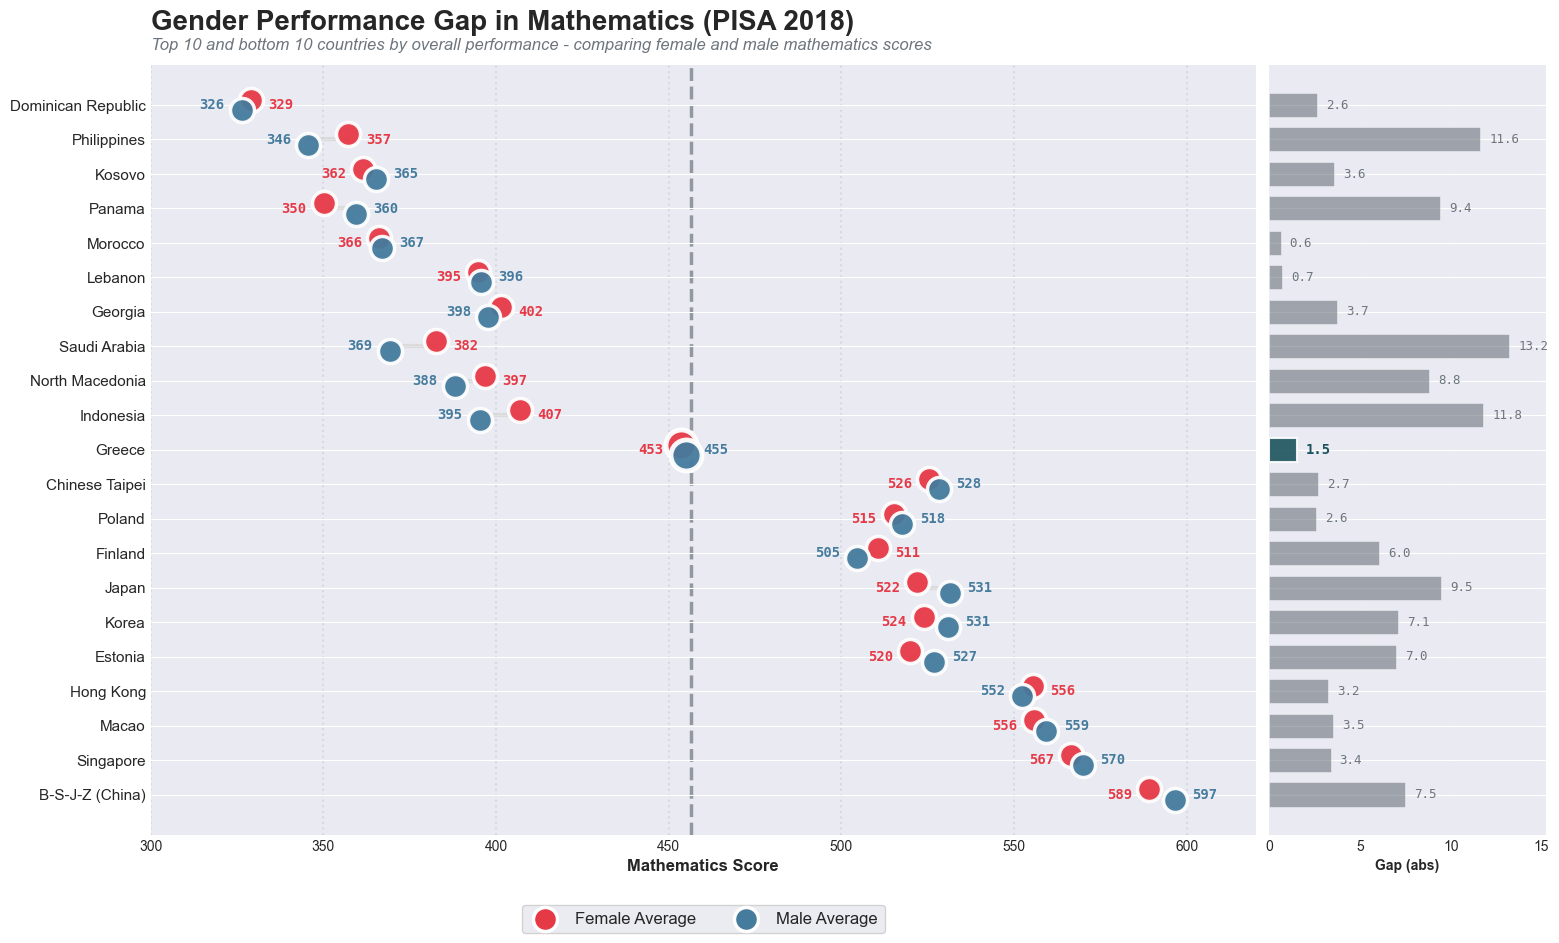

In [15]:
fig, (ax_main, ax_gap) = plt.subplots(1, 2, figsize=(18, 10), 
                                       gridspec_kw={'width_ratios': [4, 1], 'wspace': 0.02})

plot_data = gender_gaps[['MATH_Male', 'MATH_Female', 'MATH_Gap']].join(country_means[['Average_Score']])
plot_data = plot_data.dropna()
plot_data_sorted = plot_data.sort_values('Average_Score', ascending=False)

top_10 = plot_data_sorted.head(10)
bottom_10 = plot_data_sorted.tail(10)

if 'Greece' in plot_data_sorted.index:
    greece_row = plot_data_sorted.loc[['Greece']]
    selected_countries = pd.concat([top_10, greece_row, bottom_10])
else:
    selected_countries = pd.concat([top_10, bottom_10])

selected_countries = selected_countries[~selected_countries.index.duplicated(keep='first')]

global_avg = selected_countries[['MATH_Male', 'MATH_Female']].mean().mean()

offset = 0.15

# Main plot
for i, (country, row) in enumerate(selected_countries.iterrows()):
    is_greece = (country == 'Greece')
    
    line_color = '#1A535C' if is_greece else '#D1D1D1'
    line_width = 7 if is_greece else 3
    line_alpha = 1.0 if is_greece else 0.6
    
    ax_main.plot([row['MATH_Female'], row['MATH_Male']], [i, i], 
           color=line_color, linewidth=line_width, alpha=line_alpha,
           solid_capstyle='round', zorder=1)
    
    dot_size = 500 if is_greece else 300
    edge_width = 3.5 if is_greece else 2.5
    
    ax_main.scatter(row['MATH_Female'], i + offset, s=dot_size, 
              color='#E63946', edgecolors='white', linewidths=edge_width, 
              zorder=3, alpha=0.95)
    ax_main.scatter(row['MATH_Male'], i - offset, s=dot_size, 
              color='#457B9D', edgecolors='white', linewidths=edge_width, 
              zorder=3, alpha=0.95)
    
    female_label = f"{row['MATH_Female']:.0f}"
    male_label = f"{row['MATH_Male']:.0f}"
    
    if row['MATH_Female'] < row['MATH_Male']:
        ax_main.text(row['MATH_Female'] - 5, i, female_label, 
               va='center', ha='right', fontsize=10, fontweight='bold', 
               color='#E63946', family='monospace')
        ax_main.text(row['MATH_Male'] + 5, i, male_label, 
               va='center', ha='left', fontsize=10, fontweight='bold', 
               color='#457B9D', family='monospace')
    else:
        ax_main.text(row['MATH_Male'] - 5, i, male_label, 
               va='center', ha='right', fontsize=10, fontweight='bold', 
               color='#457B9D', family='monospace')
        ax_main.text(row['MATH_Female'] + 5, i, female_label, 
               va='center', ha='left', fontsize=10, fontweight='bold', 
               color='#E63946', family='monospace')

# Gap panel
for i, (country, row) in enumerate(selected_countries.iterrows()):
    is_greece = (country == 'Greece')
    gap = abs(row['MATH_Gap'])
    
    bar_color = '#1A535C' if is_greece else '#6C757D'
    bar_alpha = 0.9 if is_greece else 0.6
    
    ax_gap.barh(i, gap, height=0.7, color=bar_color, alpha=bar_alpha, 
                edgecolor='white', linewidth=1.5 if is_greece else 0.5)
    
    ax_gap.text(gap + 0.5, i, f"{gap:.1f}", va='center', ha='left',
                fontsize=10 if is_greece else 9, fontweight='bold' if is_greece else 'normal',
                color=bar_color, family='monospace')

ax_main.axvline(x=global_avg, color='#6C757D', linestyle='--', 
          linewidth=2.5, alpha=0.7, zorder=0)

ax_main.set_yticks(range(len(selected_countries)))
ax_main.set_yticklabels(selected_countries.index, fontsize=11, fontfamily='sans-serif')

ax_main.set_xlabel('Mathematics Score', fontsize=12, fontweight='bold')
ax_main.set_title('Gender Performance Gap in Mathematics (PISA 2018)', 
            fontsize=20, fontweight='bold', pad=25, loc='left', family='sans-serif')
ax_main.text(0, 1.02, 'Top 10 and bottom 10 countries by overall performance - comparing female and male mathematics scores', 
       transform=ax_main.transAxes, fontsize=12, style='italic', color='#6C757D')

legend_y = -0.08
ax_main.scatter([], [], s=300, color='#E63946', edgecolors='white', linewidths=2.5, label='Female Average')
ax_main.scatter([], [], s=300, color='#457B9D', edgecolors='white', linewidths=2.5, label='Male Average')
ax_main.legend(loc='upper center', bbox_to_anchor=(0.5, legend_y), 
         ncol=3, frameon=True, framealpha=0.95, 
         fontsize=12, edgecolor='#D1D1D1', fancybox=True)

ax_main.set_xlim(300, 620)

for spine in ax_main.spines.values():
    spine.set_visible(False)

ax_main.tick_params(left=False, bottom=True)
ax_main.set_xticks(range(300, 621, 50))
ax_main.tick_params(axis='x', labelsize=10, color='#6C757D')
ax_main.grid(axis='x', alpha=0.15, linestyle=':', linewidth=1.5, color='#6C757D')

# Gap panel styling
ax_gap.set_yticks(range(len(selected_countries)))
ax_gap.set_yticklabels([])
ax_gap.set_ylim(ax_main.get_ylim())
ax_gap.set_xlabel('Gap (abs)', fontsize=10, fontweight='bold')
ax_gap.set_xlim(0, max(abs(selected_countries['MATH_Gap'])) + 2)
ax_gap.tick_params(left=False, bottom=True)
ax_gap.grid(axis='x', alpha=0.15, linestyle=':', linewidth=1)

for spine in ax_gap.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

### Plot Number 2

/var/folders/27/w24km3fs2vl7bm7hlvrwm2l40000gn/T/ipykernel_48131/1396633485.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  country_scores = df.groupby('CNT')[['MATH', 'READ', 'SCIE']].mean()


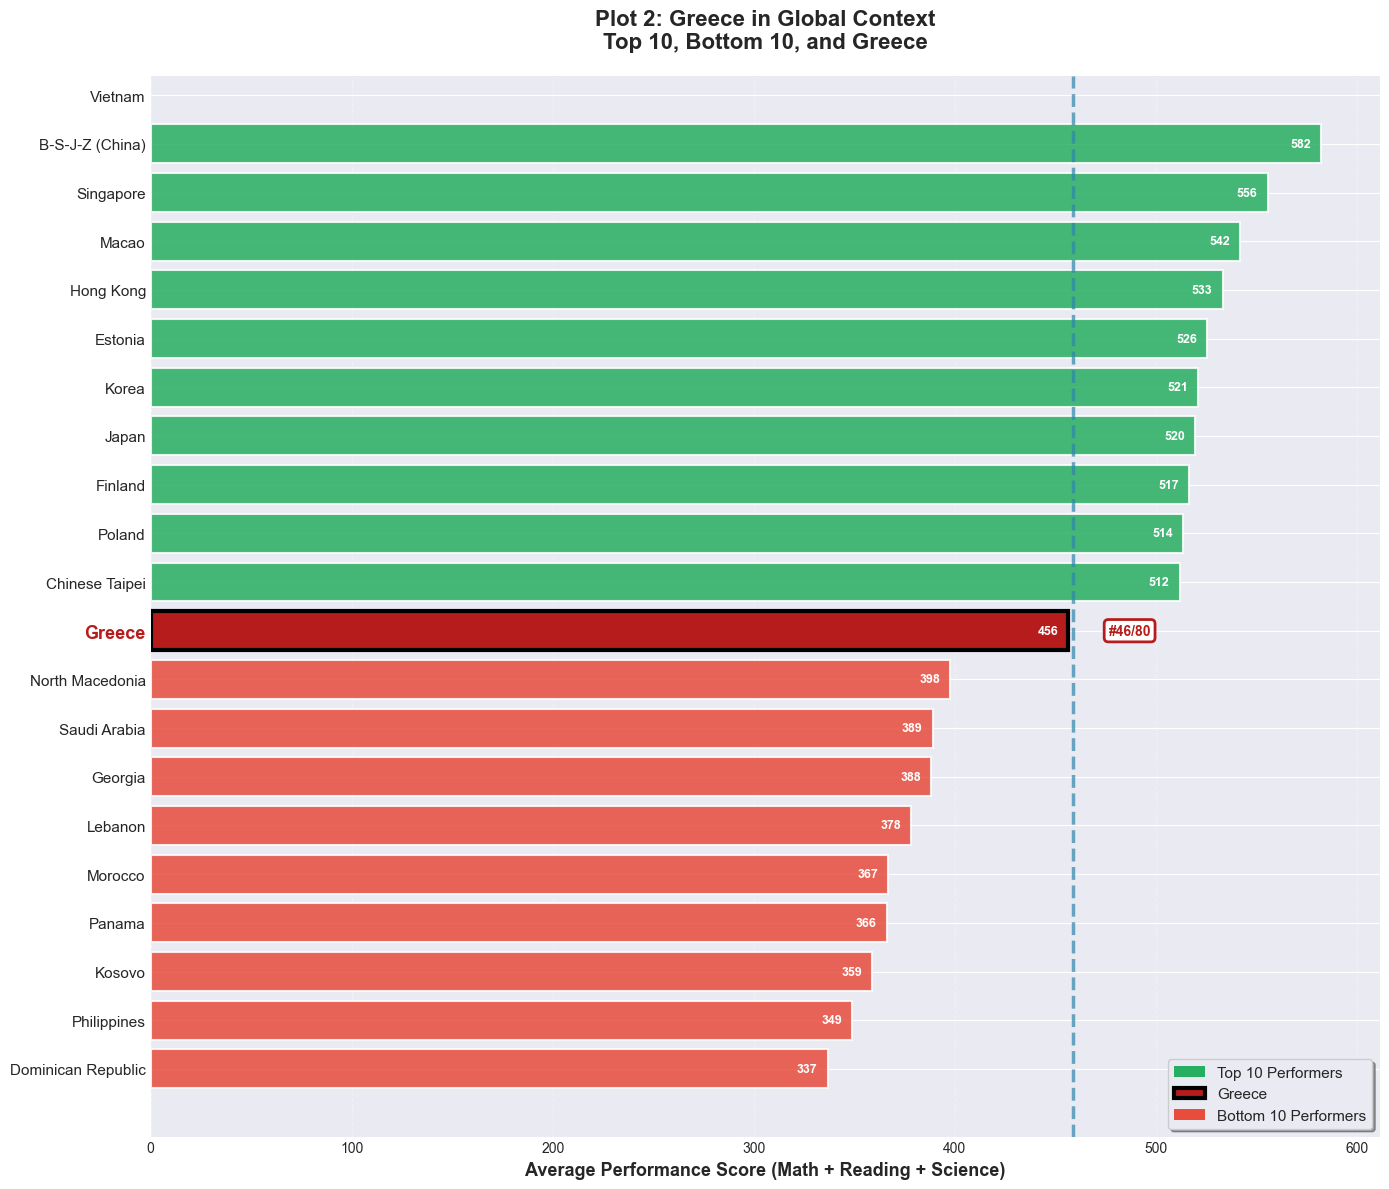

In [16]:
# Calculate country averages
country_scores = df.groupby('CNT')[['MATH', 'READ', 'SCIE']].mean()
country_scores['Average'] = country_scores.mean(axis=1)
country_scores = country_scores.sort_values('Average', ascending=False)

# Get top 10, bottom 10, and Greece
top_10 = country_scores.head(10)
bottom_10 = country_scores.tail(10)

# Create selection
if 'Greece' in country_scores.index:
    greece_rank = list(country_scores.index).index('Greece') + 1
    greece_data = country_scores.loc[['Greece']]
    
    # Combine: Top 10 + Greece + Bottom 10 (remove duplicates)
    selected = pd.concat([top_10, greece_data, bottom_10]).drop_duplicates()
else:
    selected = pd.concat([top_10, bottom_10])

# Sort by average score
selected = selected.sort_values('Average', ascending=True)

# Create horizontal bar chart
fig, ax = plt.subplots(figsize=(14, 12))

y_pos = np.arange(len(selected))

# Color coding
colors = []
for country in selected.index:
    if country == 'Greece':
        colors.append('#B71C1C')  # Dark red for Greece
    elif country in top_10.index:
        colors.append('#27AE60')  # Green for top performers
    elif country in bottom_10.index:
        colors.append('#E74C3C')  # Red for bottom performers
    else:
        colors.append('#95A5A6')  # Gray for others

# Plot bars
bars = ax.barh(y_pos, selected['Average'], color=colors, alpha=0.85,
              edgecolor='white', linewidth=1.5)

# Highlight Greece with special styling
if 'Greece' in selected.index:
    greece_idx = list(selected.index).index('Greece')
    bars[greece_idx].set_edgecolor('black')
    bars[greece_idx].set_linewidth(3)
    bars[greece_idx].set_alpha(1.0)
    
    # Add rank annotation (no star)
    greece_score = selected.loc['Greece', 'Average']
    ax.text(greece_score + 20, greece_idx, f'#{greece_rank}/{len(country_scores)}',
           fontsize=10, fontweight='bold', color='#B71C1C', va='center',
           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                    edgecolor='#B71C1C', linewidth=2))

# Add value labels on bars
for i, (bar, score) in enumerate(zip(bars, selected['Average'])):
    ax.text(score - 5, i, f'{score:.0f}', ha='right', va='center',
           fontsize=9, fontweight='bold', color='white')

# Customize
ax.set_yticks(y_pos)
ax.set_yticklabels(selected.index, fontsize=11)

# Bold Greece
if 'Greece' in selected.index:
    labels = ax.get_yticklabels()
    labels[list(selected.index).index('Greece')].set_fontweight('bold')
    labels[list(selected.index).index('Greece')].set_fontsize(13)
    labels[list(selected.index).index('Greece')].set_color('#B71C1C')

ax.set_xlabel('Average Performance Score (Math + Reading + Science)', fontsize=13, fontweight='bold')
ax.set_title('Plot 2: Greece in Global Context\nTop 10, Bottom 10, and Greece',
             fontsize=16, fontweight='bold', pad=20)

# Add ONLY global average line (removed PISA Midpoint for clarity)
global_avg = country_scores['Average'].mean()
ax.axvline(x=global_avg, color='#2E86AB', linewidth=2.5, linestyle='--', alpha=0.7)
# ax.text(global_avg + 2, len(selected)-0.5, f'Global Avg\\n({global_avg:.0f})',
#        fontsize=10, color='#2E86AB', style='italic', fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#27AE60', label='Top 10 Performers'),
    Patch(facecolor='#B71C1C', edgecolor='black', linewidth=3, label='Greece'),
    Patch(facecolor='#E74C3C', label='Bottom 10 Performers')
]
ax.legend(handles=legend_elements, loc='lower right', frameon=True,
         fontsize=11, fancybox=True, shadow=True)

# Grid
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# # Add sections labels
# ax.text(0.02, 0.95, 'TOP PERFORMERS', transform=ax.transAxes,
#        fontsize=11, fontweight='bold', color='#27AE60', style='italic',
#        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.7))

# ax.text(0.02, 0.05, 'BOTTOM PERFORMERS', transform=ax.transAxes,
#        fontsize=11, fontweight='bold', color='#E74C3C', style='italic',
#        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.7))

# Data source
ax.text(0.98, 0.02, 'Data: OECD PISA 2018', transform=ax.transAxes,
        fontsize=9, va='bottom', ha='right', color='#6C757D', style='italic')

plt.tight_layout()
plt.show()

### Plot Number 3

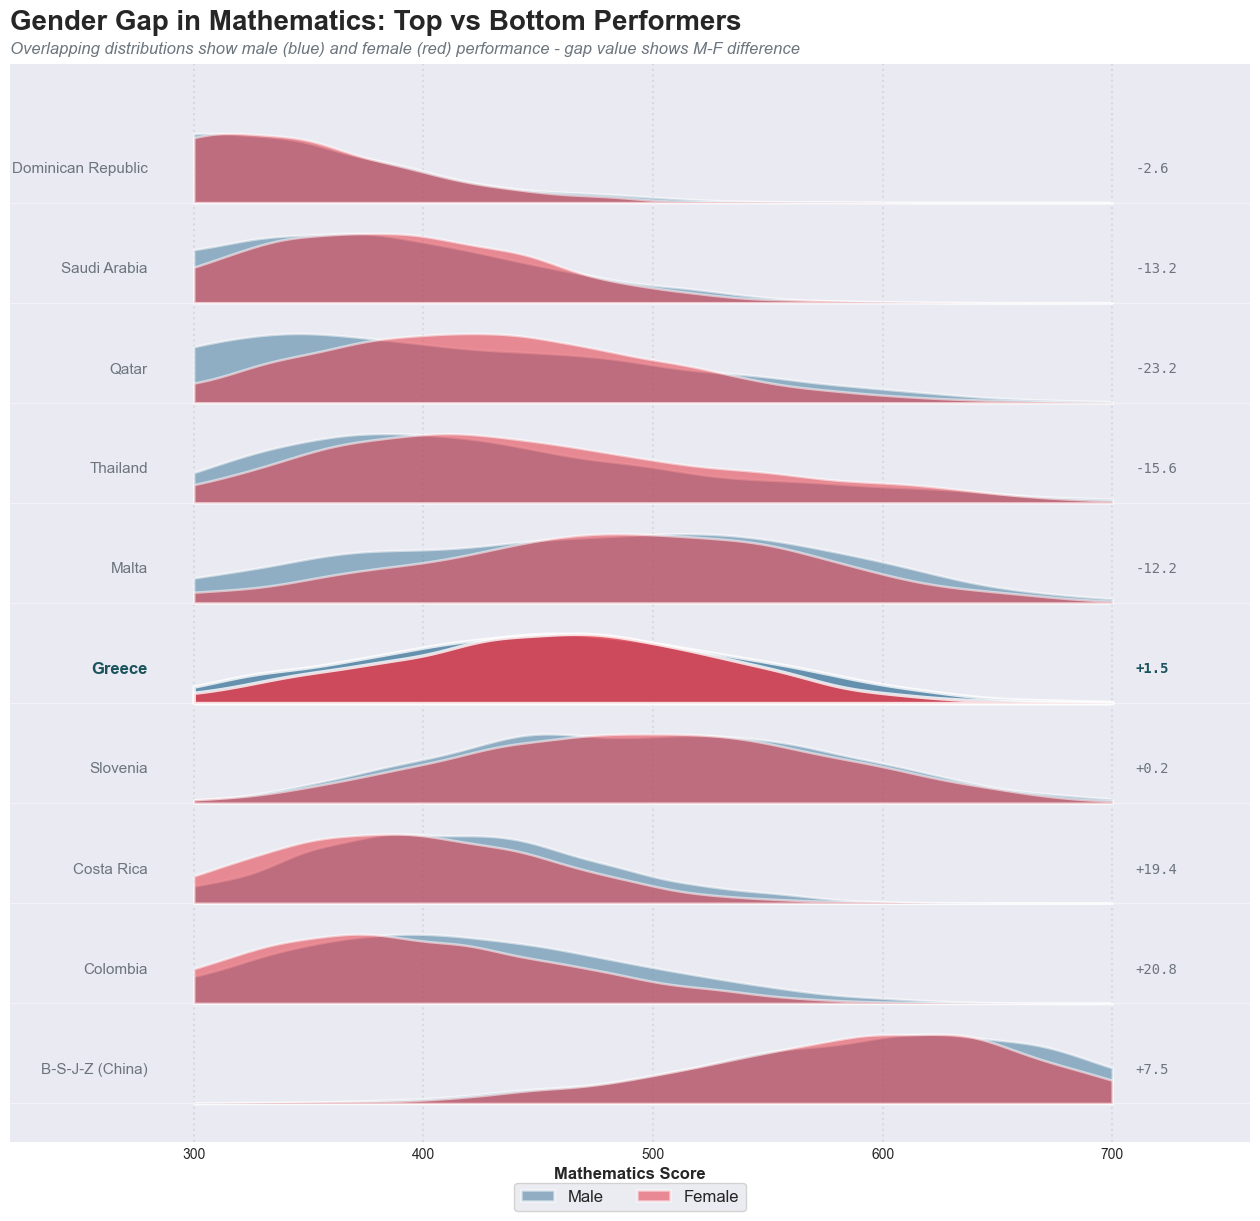

In [17]:
fig, ax = plt.subplots(figsize=(16, 14))

selected_countries = [
    'B-S-J-Z (China)',      # Top performer
    'Colombia',             # Largest gap (boys >>)
    'Costa Rica',           # Large gap (boys >>)
    'Slovenia',             # Most equal
    'Greece',               # Our focus
    'Malta',                # High perf + girls better
    'Thailand',             # Girls better
    'Qatar',                # Largest negative gap (girls >>)
    'Saudi Arabia',         # Girls better (cultural interest)
    'Dominican Republic'    # Bottom performer
]

selected_countries = [c for c in selected_countries if c in df['CNT'].values and c in gender_gaps.index]

ridge_height = 0.9
spacing = 1.3
x_min, x_max = 300, 700

for i, country in enumerate(selected_countries):
    country_male = df[(df['CNT'] == country) & (df['ST004D01T'] == 'Male')]['MATH'].dropna()
    country_female = df[(df['CNT'] == country) & (df['ST004D01T'] == 'Female')]['MATH'].dropna()
    
    y_base = i * spacing
    
    is_greece = (country == 'Greece')
    alpha_val = 0.8 if is_greece else 0.55
    edge_width = 2.5 if is_greece else 1.8
    
    if len(country_male) > 50:
        kde_male = gaussian_kde(country_male)
        x_range = np.linspace(x_min, x_max, 500)
        density_male = kde_male(x_range)
        density_male_scaled = density_male / density_male.max() * ridge_height
        
        ax.fill_between(x_range, y_base, y_base + density_male_scaled, 
                       alpha=alpha_val, color='#457B9D', edgecolor='white', 
                       linewidth=edge_width, zorder=5, label='Male' if i == 0 else '')
    
    if len(country_female) > 50:
        kde_female = gaussian_kde(country_female)
        x_range = np.linspace(x_min, x_max, 500)
        density_female = kde_female(x_range)
        density_female_scaled = density_female / density_female.max() * ridge_height
        
        ax.fill_between(x_range, y_base, y_base + density_female_scaled, 
                       alpha=alpha_val, color='#E63946', edgecolor='white', 
                       linewidth=edge_width, zorder=6, label='Female' if i == 0 else '')
    
    ax.axhline(y=y_base, color='white', linewidth=0.8, alpha=0.4, zorder=3)
    
    country_label = f'{country}' if is_greece else country
    fontweight = 'bold' if is_greece else 'normal'
    fontsize = 12 if is_greece else 11
    label_color = '#1A535C' if is_greece else '#6C757D'
    
    ax.text(x_min - 20, y_base + ridge_height/2, country_label, 
           va='center', ha='right', fontsize=fontsize, fontweight=fontweight, 
           color=label_color, family='sans-serif')
    
    male_mean = country_male.mean()
    female_mean = country_female.mean()
    gap = male_mean - female_mean
    
    gap_color = '#1A535C' if is_greece else '#6C757D'
    ax.text(x_max + 10, y_base + ridge_height/2, f'{gap:+.1f}', 
           va='center', ha='left', fontsize=10, fontweight='bold' if is_greece else 'normal',
           color=gap_color, family='monospace')

ax.set_xlim(x_min - 80, x_max + 60)
ax.set_ylim(-0.5, len(selected_countries) * spacing + 0.5)

ax.set_xlabel('Mathematics Score', fontsize=12, fontweight='bold', family='sans-serif')
ax.set_ylabel('')
ax.set_title('Gender Gap in Mathematics: Top vs Bottom Performers', 
            fontsize=20, fontweight='bold', pad=25, loc='left', family='sans-serif')
ax.text(0, 1.01, 'Overlapping distributions show male (blue) and female (red) performance - gap value shows M-F difference', 
       transform=ax.transAxes, fontsize=12, style='italic', color='#6C757D')

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.03), 
         ncol=2, frameon=True, framealpha=0.95, 
         fontsize=12, edgecolor='#D1D1D1', fancybox=True)

ax.set_yticks([])
ax.grid(axis='x', alpha=0.15, linestyle=':', linewidth=1.5, color='#6C757D')

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(left=False, bottom=True)
ax.tick_params(axis='x', labelsize=10, color='#6C757D')

# plt.tight_layout()
plt.show()

### Plot Number 4

Top regional performer: Spain
Bottom regional performer: Albania


/var/folders/27/w24km3fs2vl7bm7hlvrwm2l40000gn/T/ipykernel_48131/1818403984.py:189: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


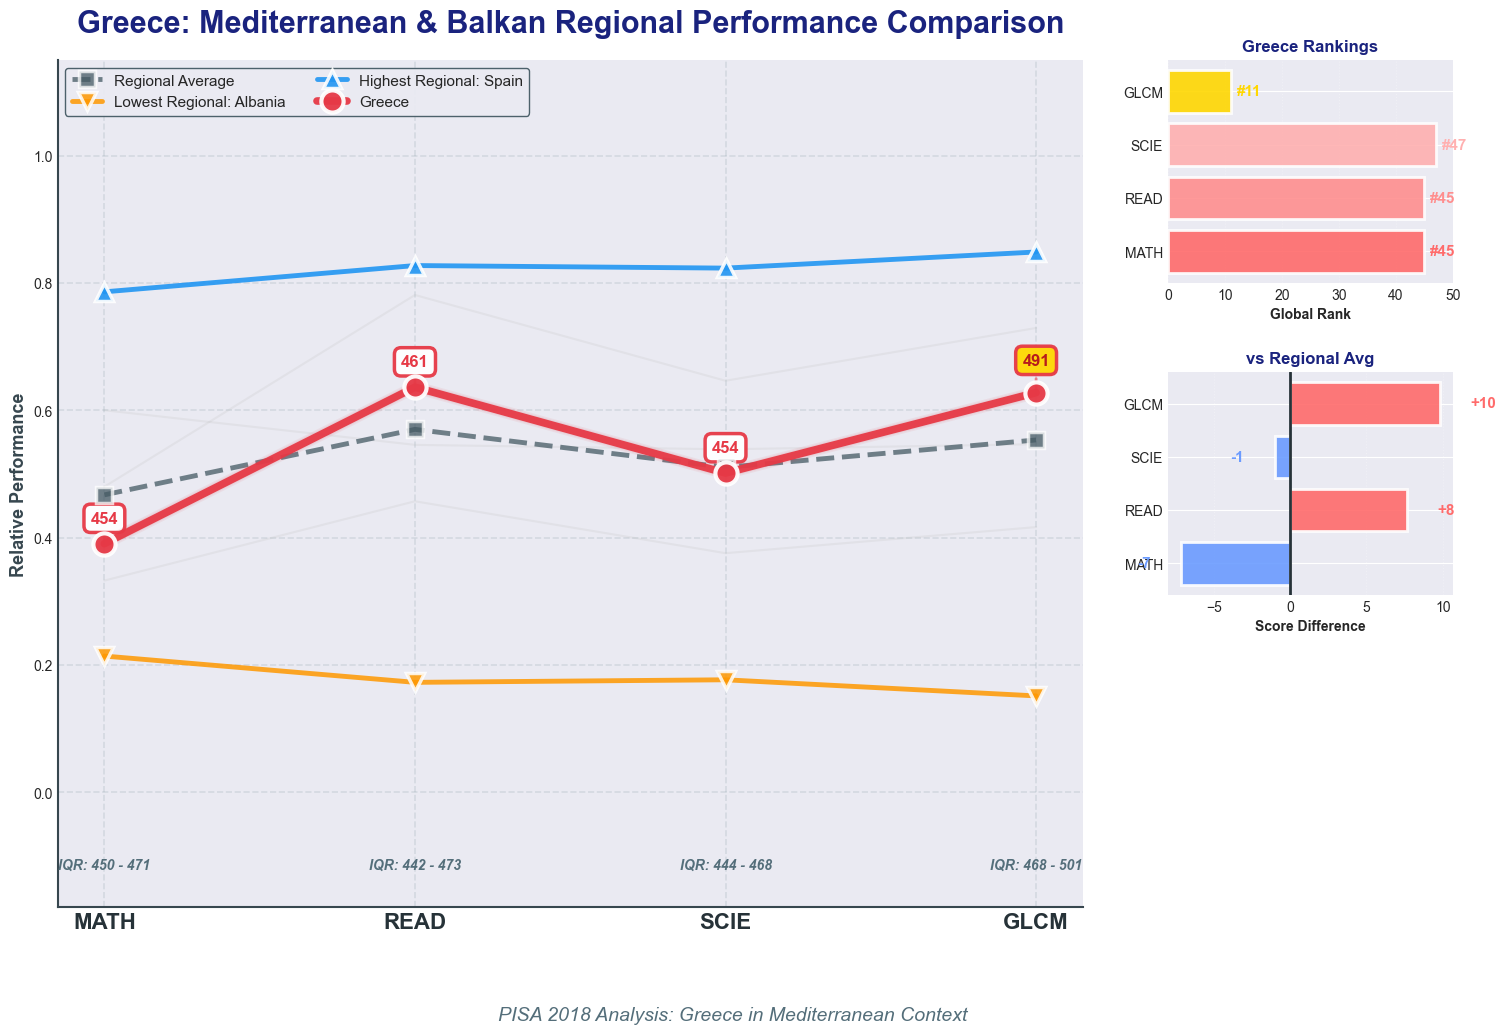


Greece vs Regional Performers:

Greece: {'MATH': 454.2, 'READ': 460.6, 'SCIE': 454.3, 'GLCM': 491.1}
Regional Average: {'MATH': 461.4, 'READ': 453.0, 'SCIE': 455.3, 'GLCM': 481.3}
Spain: {'MATH': 491.2, 'READ': 482.7, 'SCIE': 490.7, 'GLCM': 520.3}


In [18]:
# Create parallel coordinates with better visibility and quartile ranges
fig = plt.figure(figsize=(18, 11))
gs = fig.add_gridspec(3, 4, hspace=0.4, wspace=0.3)

# Main parallel coordinates plot
ax_main = fig.add_subplot(gs[:, :3])

# Get regional data
regional_countries = [
    'Greece', 'Italy', 'Spain', 'Portugal', 'Croatia', 
    'Bulgaria', 'Romania', 'Serbia', 'Albania', 'Turkey',
    'Cyprus', 'Malta', 'Slovenia'
]

available_regional = [c for c in regional_countries if c in country_means.index]
regional_data = country_means.loc[available_regional, ['MATH', 'READ', 'SCIE', 'GLCM']].copy()
regional_data = regional_data.dropna()


# Calculate regional average
regional_avg = regional_data.mean()

# Find top and bottom performers in the region
regional_avg_scores = regional_data[['MATH', 'READ', 'SCIE']].mean(axis=1)
top_regional = regional_avg_scores.idxmax()
bottom_regional = regional_avg_scores.idxmin()

print(f"Top regional performer: {top_regional}")
print(f"Bottom regional performer: {bottom_regional}")

# Add top/bottom regional performers to the data for normalization
display_data = regional_data.copy()

# Use extended range for normalization
regional_data_norm = pd.DataFrame(index=display_data.index, columns=SUBJECTS)
q25_vals = {}
q75_vals = {}

for subject in SUBJECTS:
    q25 = display_data[subject].quantile(0.25)
    q75 = display_data[subject].quantile(0.75)
    q25_vals[subject] = q25
    q75_vals[subject] = q75
    
    # Normalize using a wider range for better visibility
    min_val = display_data[subject].min() - 20
    max_val = display_data[subject].max() + 20
    regional_data_norm[subject] = (display_data[subject] - min_val) / (max_val - min_val)

# Normalize regional average
regional_avg_norm = pd.Series(index=SUBJECTS)
for subject in SUBJECTS:
    min_val = display_data[subject].min() - 20
    max_val = display_data[subject].max() + 20
    regional_avg_norm[subject] = (regional_avg[subject] - min_val) / (max_val - min_val)

positions = np.arange(len(SUBJECTS))

# Plot background countries with very light styling
for country in regional_data_norm.index:
    if country not in ['Greece', top_regional, bottom_regional]:
        values = regional_data_norm.loc[country].values
        ax_main.plot(positions, values, linewidth=1.5, alpha=0.2, 
                    color='#BDBDBD', zorder=2)

# Plot regional average line
ax_main.plot(positions, regional_avg_norm.values, 
            linewidth=3.5, linestyle='--', color='#455A64', alpha=0.75,
            marker='s', markersize=11, markeredgewidth=2.5, markeredgecolor='white',
            label='Regional Average', zorder=6)

# Plot bottom regional performer
if bottom_regional != 'Greece':
    bottom_values = regional_data_norm.loc[bottom_regional].values
    ax_main.plot(positions, bottom_values, 
                linewidth=3.5, color='#FF9800', alpha=0.85,
                marker='v', markersize=13, markeredgewidth=2.5, markeredgecolor='white',
                label=f'Lowest Regional: {bottom_regional}', zorder=7)

# Plot top regional performer
if top_regional != 'Greece':
    top_values = regional_data_norm.loc[top_regional].values
    ax_main.plot(positions, top_values, 
                linewidth=3.5, color='#2196F3', alpha=0.9,
                marker='^', markersize=13, markeredgewidth=2.5, markeredgecolor='white',
                label=f'Highest Regional: {top_regional}', zorder=8)

# Plot GREECE prominently
greece_values = regional_data_norm.loc['Greece'].values
ax_main.plot(positions, greece_values, 
            linewidth=5.5, color='#E63946', alpha=0.95,
            marker='o', markersize=16, markeredgewidth=3, markeredgecolor='white',
            label='Greece', zorder=10, solid_capstyle='round')

# Add subtle glow effect for Greece
for width in [7, 9]:
    ax_main.plot(positions, greece_values, linewidth=width, 
                color='#E63946', alpha=0.08, zorder=9)

# Annotate actual scores on Greece line - FIXED
for i, (pos, val) in enumerate(zip(positions, greece_values)):
    actual_score = display_data.loc['Greece', SUBJECTS[i]]
    rank = country_means[f'{SUBJECTS[i]}_Rank'].loc['Greece']
    
    if SUBJECTS[i] == 'GLCM':
        bbox_color = '#FFD700'
        text_color = '#B71C1C'
        offset_y = 20
    else:
        bbox_color = 'white'
        text_color = '#E63946'
        offset_y = 15
    
    ax_main.annotate(f'{actual_score:.0f}', 
                    xy=(pos, val), xytext=(0, offset_y), textcoords='offset points',
                    fontsize=12, fontweight='bold', color=text_color, ha='center',
                    bbox=dict(boxstyle='round,pad=0.4', facecolor=bbox_color, 
                             edgecolor='#E63946', linewidth=2.5, alpha=0.95),
                    arrowprops=dict(arrowstyle='-', lw=2, color='#E63946', alpha=0.6))

# Styling
ax_main.set_xticks(positions)
ax_main.set_xticklabels(SUBJECTS, fontsize=16, fontweight='bold', color='#263238')
ax_main.set_ylabel('Relative Performance', fontsize=13, fontweight='bold', color='#37474F')
ax_main.set_title('Greece: Mediterranean & Balkan Regional Performance Comparison', 
                 fontsize=22, fontweight='bold', pad=20, color='#1A237E')

# Add IQR ranges below
for i, subject in enumerate(SUBJECTS):
    q25 = q25_vals[subject]
    q75 = q75_vals[subject]
    ax_main.text(i, -0.12, f'IQR: {q25:.0f} - {q75:.0f}', 
                ha='center', fontsize=10, color='#546E7A', 
                style='italic', weight='bold')

ax_main.set_ylim(-0.18, 1.15)
ax_main.grid(axis='both', alpha=0.25, linestyle='--', linewidth=1.2, color='#90A4AE')

# Legend
ax_main.legend(loc='upper left', fontsize=11, frameon=True, 
              framealpha=0.95, edgecolor='#455A64', fancybox=True,
              shadow=False, ncol=2)

for spine in ['top', 'right']:
    ax_main.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax_main.spines[spine].set_linewidth(1.5)
    ax_main.spines[spine].set_color('#37474F')

# Side panel 1: Rank comparison bars
ax_ranks = fig.add_subplot(gs[0, 3])
greece_ranks = [country_means.loc['Greece', f'{s}_Rank'] for s in SUBJECTS]
colors_rank = ['#FF6B6B', '#FF8E8E', '#FFB0B0', '#FFD700']

bars = ax_ranks.barh(SUBJECTS, greece_ranks, color=colors_rank, 
                     edgecolor='white', linewidth=2, alpha=0.9)
for i, (bar, rank) in enumerate(zip(bars, greece_ranks)):
    ax_ranks.text(rank + 1, i, f'#{int(rank)}', va='center', 
                 fontsize=11, fontweight='bold', color=colors_rank[i])

ax_ranks.set_xlim(50, 0)
ax_ranks.set_xlabel('Global Rank', fontsize=10, fontweight='bold')
ax_ranks.set_title('Greece Rankings', fontsize=12, fontweight='bold', color='#1A237E')
ax_ranks.grid(axis='x', alpha=0.3, linestyle=':')
ax_ranks.invert_xaxis()

# Side panel 2: Score differences from regional average
ax_diff = fig.add_subplot(gs[1, 3])
greece_scores = [display_data.loc['Greece', s] for s in SUBJECTS]
avg_scores = [regional_avg[s] for s in SUBJECTS]
differences = [g - a for g, a in zip(greece_scores, avg_scores)]

colors_diff = ['#FF6B6B' if d > 0 else '#6B9BFF' for d in differences]
bars2 = ax_diff.barh(SUBJECTS, differences, color=colors_diff, 
                     edgecolor='white', linewidth=2, alpha=0.9)
for i, (bar, diff) in enumerate(zip(bars2, differences)):
    ax_diff.text(diff + (2 if diff > 0 else -2), i, f'{diff:+.0f}', 
                va='center', ha='left' if diff > 0 else 'right',
                fontsize=11, fontweight='bold', color=colors_diff[i])

ax_diff.axvline(x=0, color='#263238', linewidth=2, linestyle='-')
ax_diff.set_xlabel('Score Difference', fontsize=10, fontweight='bold')
ax_diff.set_title('vs Regional Avg', fontsize=12, fontweight='bold', color='#1A237E')
ax_diff.grid(axis='x', alpha=0.3, linestyle=':')

plt.suptitle('PISA 2018 Analysis: Greece in Mediterranean Context', 
            fontsize=14, color='#546E7A', style='italic', y=0.02)

plt.tight_layout()
plt.show()

print("\nGreece vs Regional Performers:")
print(f"\nGreece: {display_data.loc['Greece'].round(1).to_dict()}")
print(f"Regional Average: {regional_avg.round(1).to_dict()}")
print(f"{top_regional}: {display_data.loc[top_regional].round(1).to_dict()}")

### Plot Number 5

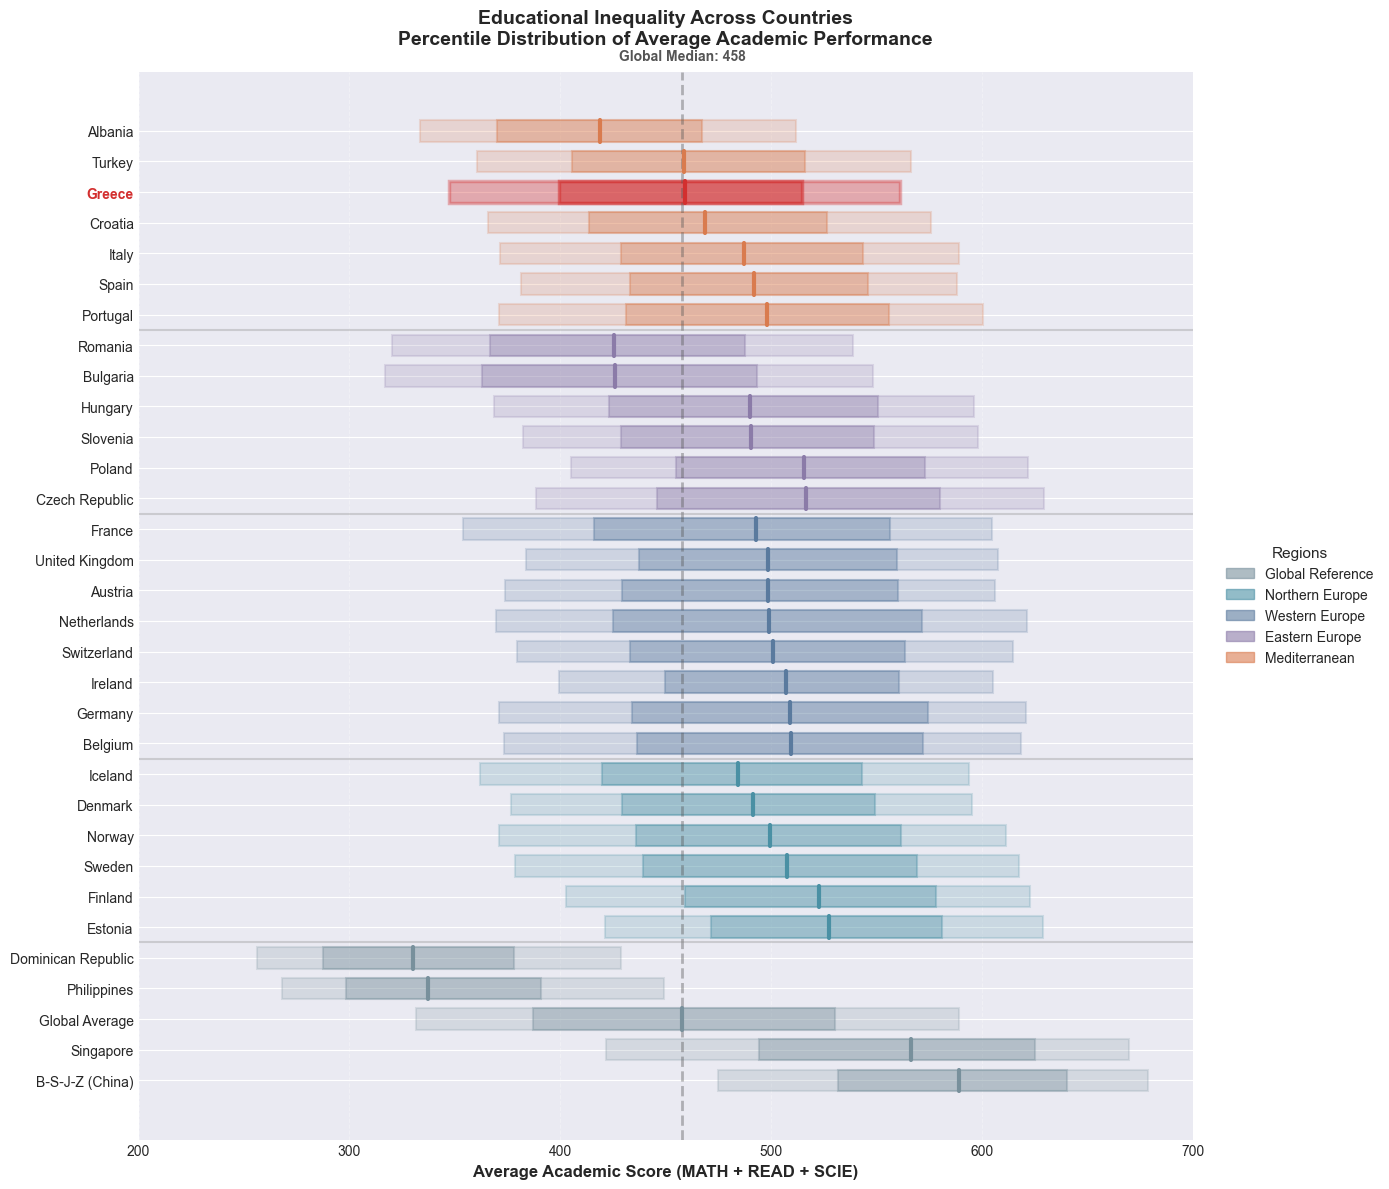

In [19]:
# Calculate average academic score (MATH + READ + SCIE)
df['AVG_ACADEMIC'] = df[['MATH', 'READ', 'SCIE']].mean(axis=1)

# Define regions with their countries and colors
regions_config = {
    'Global Reference': {
        'countries': ['B-S-J-Z (China)', 'Singapore', 'Global Average', 'Dominican Republic', 'Philippines'],
        'color': '#78909C'
    },
    'Northern Europe': {
        'countries': ['Finland', 'Estonia', 'Sweden', 'Denmark', 'Norway', 'Iceland'],
        'color': '#4A90A4'
    },
    'Western Europe': {
        'countries': ['Netherlands', 'Belgium', 'Switzerland', 'Germany', 'France', 'United Kingdom', 'Ireland', 'Austria'],
        'color': '#5A7A9E'
    },
    'Eastern Europe': {
        'countries': ['Poland', 'Czech Republic', 'Slovenia', 'Hungary', 'Slovakia', 'Romania', 'Bulgaria'],
        'color': '#8B7BA8'
    },
    'Mediterranean': {
        'countries': ['Greece', 'Italy', 'Spain', 'Portugal', 'Croatia', 'Turkey', 'Albania'],
        'color': '#D97B4E'
    }
}

# Flatten to create country-to-region and country-to-color mappings
country_to_region = {}
country_to_color = {}
for region, config in regions_config.items():
    for country in config['countries']:
        country_to_region[country] = region
        country_to_color[country] = config['color']

# Calculate percentiles
selected_countries = [c for region_data in regions_config.values() for c in region_data['countries'] if c != 'Global Average']
percentile_data = []

for country in selected_countries:
    country_data = df[df['CNT'] == country]['AVG_ACADEMIC'].dropna()
    if len(country_data) > 0:
        percentiles = {
            'Country': country,
            '10th': np.percentile(country_data, 10),
            '25th': np.percentile(country_data, 25),
            '50th': np.percentile(country_data, 50),
            '75th': np.percentile(country_data, 75),
            '90th': np.percentile(country_data, 90),
            'Region': country_to_region[country],
            'Color': country_to_color[country]
        }
        percentile_data.append(percentiles)

# Add global average
all_scores = df['AVG_ACADEMIC'].dropna()
global_avg = {
    'Country': 'Global Average',
    '10th': np.percentile(all_scores, 10),
    '25th': np.percentile(all_scores, 25),
    '50th': np.percentile(all_scores, 50),
    '75th': np.percentile(all_scores, 75),
    '90th': np.percentile(all_scores, 90),
    'Region': 'Global Reference',
    'Color': country_to_color['Global Average']
}
percentile_data.append(global_avg)

df_percentiles = pd.DataFrame(percentile_data)
df_percentiles['Spread'] = df_percentiles['90th'] - df_percentiles['10th']

# Group by region instead of sorting by median
region_order = ['Global Reference', 'Northern Europe', 'Western Europe', 'Eastern Europe', 'Mediterranean']
df_percentiles['Region'] = pd.Categorical(df_percentiles['Region'], categories=region_order, ordered=True)
df_percentiles = df_percentiles.sort_values(['Region', '50th'], ascending=[True, False]).reset_index(drop=True)

# Create plot
fig, ax = plt.subplots(figsize=(14, 12))

# Plot ribbons
for idx, row in df_percentiles.iterrows():
    y_pos = idx
    color = row['Color']
    
    if row['Country'] == 'Greece':
        color = '#D32F2F'
        alpha_outer = 0.35
        alpha_inner = 0.55
        linewidth = 2.5
    else:
        alpha_outer = 0.20
        alpha_inner = 0.35
        linewidth = 1.5
    
    # Outer ribbon (10th-90th percentile)
    ax.barh(y_pos, row['90th'] - row['10th'], left=row['10th'], 
            height=0.7, color=color, alpha=alpha_outer, edgecolor=color, linewidth=linewidth)
    
    # Inner ribbon (25th-75th percentile)
    ax.barh(y_pos, row['75th'] - row['25th'], left=row['25th'], 
            height=0.7, color=color, alpha=alpha_inner, edgecolor=color, linewidth=linewidth)
    
    # Median line
    ax.plot([row['50th'], row['50th']], [y_pos - 0.35, y_pos + 0.35], 
            color=color, linewidth=3, zorder=3)

# Add region separators
current_region = None
for idx, row in df_percentiles.iterrows():
    if row['Region'] != current_region:
        if current_region is not None:
            ax.axhline(idx - 0.5, color='gray', linestyle='-', linewidth=1.5, alpha=0.3)
        current_region = row['Region']

# Country labels
country_labels = []
for idx, row in df_percentiles.iterrows():
    if row['Country'] == 'Greece':
        country_labels.append('Greece')
    else:
        country_labels.append(row['Country'])

ax.set_yticks(range(len(df_percentiles)))
ax.set_yticklabels(country_labels, fontsize=10)

# Highlight Greece label
ytick_labels = ax.get_yticklabels()
for label in ytick_labels:
    if 'Greece' in label.get_text():
        label.set_color('#D32F2F')
        label.set_fontweight('bold')

# Add global median reference line
global_median = df_percentiles[df_percentiles['Country'] == 'Global Average']['50th'].values[0]
ax.axvline(global_median, color='#555555', linestyle='--', linewidth=2, alpha=0.4, zorder=1)
ax.text(global_median, len(df_percentiles) + 1.2, f'Global Median: {global_median:.0f}', 
        ha='center', va='bottom', fontsize=10, color='#555555', fontweight='bold')

# Create legend outside the plot
legend_elements = []
for region in region_order:
    legend_elements.append(Patch(facecolor=regions_config[region]['color'], 
                                 edgecolor=regions_config[region]['color'],
                                 label=region, alpha=0.6))

ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.02, 0.5), 
          fontsize=10, title='Regions', title_fontsize=11, framealpha=0.95)

# Formatting
ax.set_xlabel('Average Academic Score (MATH + READ + SCIE)', fontsize=12, fontweight='bold')
ax.set_title('Educational Inequality Across Countries\nPercentile Distribution of Average Academic Performance', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlim(200, 700)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

### Plot Number 6

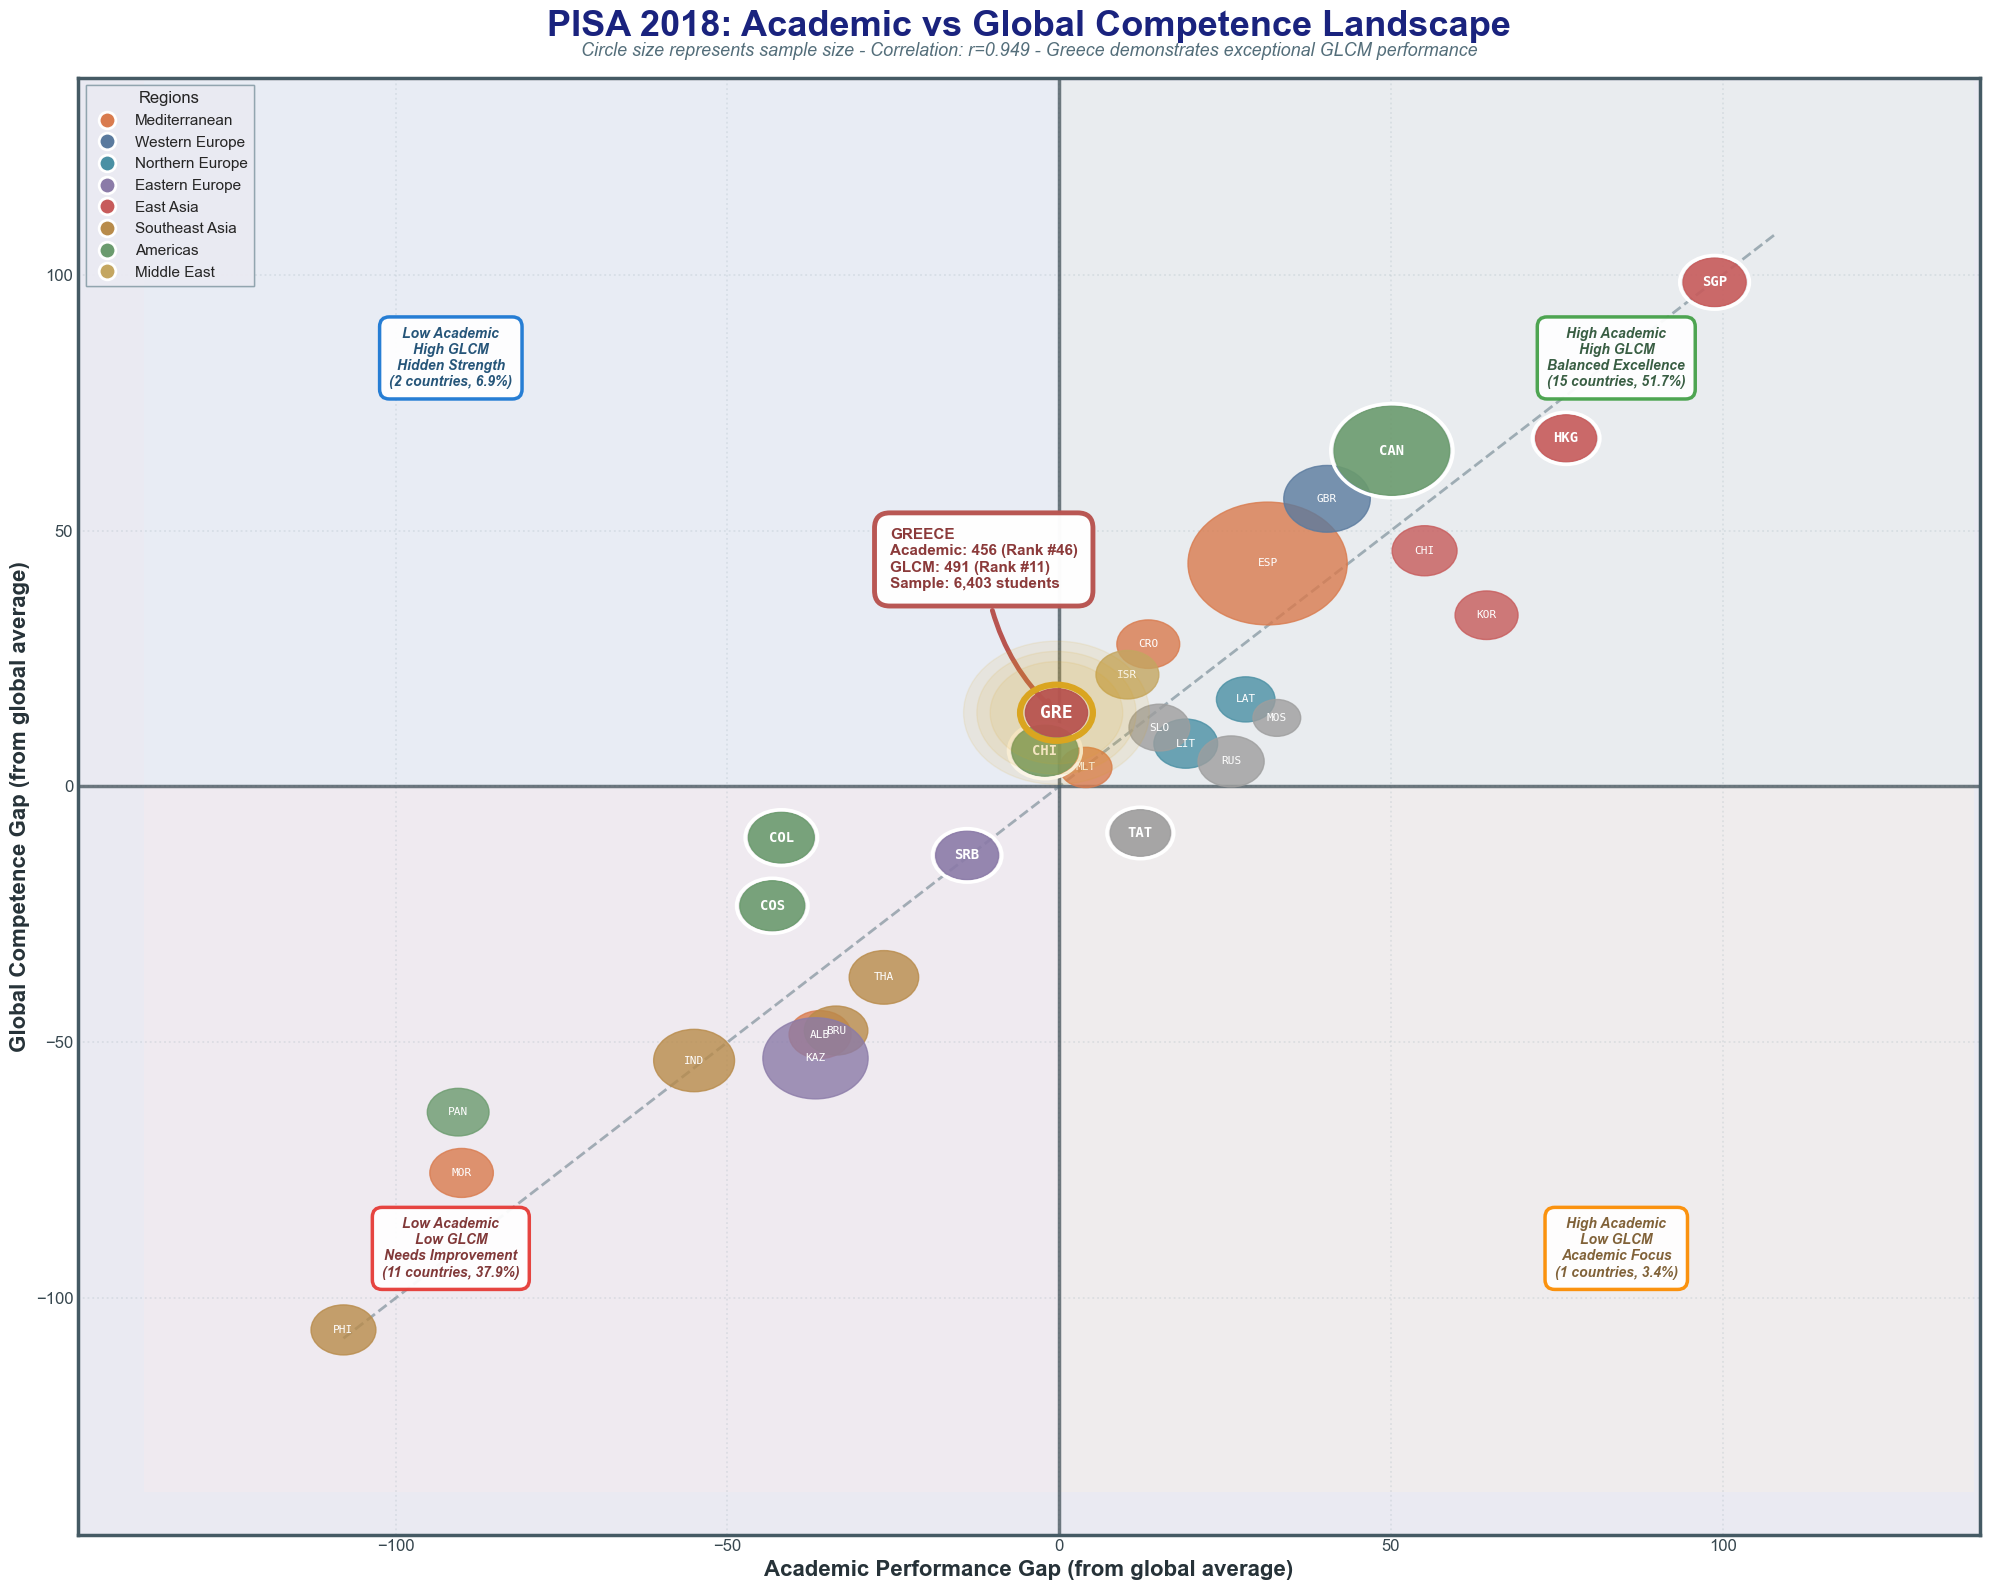

In [20]:
import pandas as pd

# Defensive checks for required variables
if 'country_stats' not in dir() or 'country_means' not in dir():
    raise NameError("Required variables not found. Please run Cell 7 (country_stats) and Cell 11 (country_means) first.")

# Ensure country_stats is a DataFrame (defensive programming)
if isinstance(country_stats, dict):
    country_stats = pd.DataFrame.from_dict(country_stats, orient='index')

# Verify country_means is a DataFrame with required columns
required_cols = ['MATH', 'READ', 'SCIE', 'GLCM']
if not isinstance(country_means, pd.DataFrame) or not all(col in country_means.columns for col in required_cols):
    raise ValueError("country_means is not properly structured. Please re-run Cell 11.")

# Regional color mapping - CLEAR BUT PROFESSIONAL
def get_region_and_color(country):
    """Get region and color - clear distinction, professional palette"""
    regions = {
        'Mediterranean': {
            'countries': ['Greece', 'Italy', 'Spain', 'Portugal', 'Cyprus', 'Malta', 
                         'Croatia', 'Albania', 'Turkey', 'Morocco', 'Tunisia', 
                         'North Macedonia', 'Montenegro', 'Bosnia and Herzegovina'],
            'color': '#D97B4E'  # Terracotta/clay
        },
        'Western Europe': {
            'countries': ['France', 'Germany', 'United Kingdom', 'Belgium', 'Netherlands',
                         'Austria', 'Switzerland', 'Luxembourg', 'Ireland'],
            'color': '#5A7A9E'  # Medium blue-gray
        },
        'Northern Europe': {
            'countries': ['Finland', 'Sweden', 'Norway', 'Denmark', 'Iceland', 
                         'Estonia', 'Latvia', 'Lithuania'],
            'color': '#4A90A4'  # Nordic blue
        },
        'Eastern Europe': {
            'countries': ['Poland', 'Czech Republic', 'Slovakia', 'Hungary', 'Romania',
                         'Bulgaria', 'Serbia', 'Slovenia', 'Russia', 'Ukraine', 
                         'Moldova', 'Georgia', 'Kazakhstan'],
            'color': '#8B7BA8'  # Muted lavender
        },
        'East Asia': {
            'countries': ['B-S-J-Z (China)', 'Japan', 'Korea', 'Hong Kong', 'Macao', 
                         'Singapore', 'Chinese Taipei'],
            'color': '#C75B5B'  # Dusty red
        },
        'Southeast Asia': {
            'countries': ['Thailand', 'Vietnam', 'Malaysia', 'Indonesia', 'Philippines',
                         'Brunei Darussalam'],
            'color': '#B88B4A'  # Warm gold
        },
        'Americas': {
            'countries': ['United States', 'Canada', 'Mexico', 'Brazil', 'Argentina',
                         'Chile', 'Colombia', 'Peru', 'Uruguay', 'Costa Rica', 
                         'Panama', 'Dominican Republic'],
            'color': '#6B9B6E'  # Sage green
        },
        'Middle East': {
            'countries': ['Saudi Arabia', 'Qatar', 'United Arab Emirates', 'Jordan',
                         'Lebanon', 'Israel', 'Baku (Azerbaijan)'],
            'color': '#C4A661'  # Sandy gold
        },
        'Oceania': {
            'countries': ['Australia', 'New Zealand'],
            'color': '#5B9AAA'  # Teal
        },
    }
    
    for region, info in regions.items():
        if country in info['countries']:
            return region, info['color']
    return 'Other', '#9E9E9E'

def get_country_code(country_name):
    """Get 2-3 letter country code"""
    codes = {
        'Greece': 'GRE', 'Albania': 'ALB', 'Italy': 'ITA', 'Spain': 'ESP',
        'Portugal': 'POR', 'Croatia': 'CRO', 'Bulgaria': 'BUL', 'Romania': 'ROM',
        'Serbia': 'SRB', 'Turkey': 'TUR', 'Cyprus': 'CYP', 'Malta': 'MLT',
        'Slovenia': 'SVN', 'Finland': 'FIN', 'Singapore': 'SGP', 'United States': 'USA',
        'B-S-J-Z (China)': 'CHN', 'Hong Kong': 'HKG', 'Macao': 'MAC', 'Japan': 'JPN',
        'Korea': 'KOR', 'Estonia': 'EST', 'Poland': 'POL', 'Germany': 'GER',
        'France': 'FRA', 'United Kingdom': 'GBR', 'Netherlands': 'NED', 'Belgium': 'BEL',
        'Austria': 'AUT', 'Switzerland': 'SUI', 'Norway': 'NOR', 'Sweden': 'SWE',
        'Denmark': 'DEN', 'Canada': 'CAN', 'Australia': 'AUS', 'New Zealand': 'NZL',
    }
    return codes.get(country_name, country_name[:3].upper())

# Create plot
fig, ax = plt.subplots(figsize=(20, 16))

# Calculate metrics
plot_countries = country_means.dropna()
sample_sizes = country_stats.loc[plot_countries.index, 'Total_Students']

# X-axis: Academic Performance
academic_scores = plot_countries[['MATH', 'READ', 'SCIE']].mean(axis=1)
global_academic_mean = academic_scores.mean()
x_values = academic_scores - global_academic_mean

# Y-axis: GLCM Performance
glcm_scores = plot_countries['GLCM']
global_glcm_mean = glcm_scores.mean()
y_values = glcm_scores - global_glcm_mean

# Calculate correlation
correlation = np.corrcoef(x_values, y_values)[0, 1]

# Background
max_range = max(abs(x_values.min()), abs(x_values.max()), 
                abs(y_values.min()), abs(y_values.max()))

# Very subtle quadrant shading
ax.add_patch(Rectangle((0, 0), max_range + 30, max_range + 30, 
                       facecolor='#E8F5E9', alpha=0.25, zorder=0))
ax.add_patch(Rectangle((-max_range - 30, 0), max_range + 30, max_range + 30, 
                       facecolor='#E3F2FD', alpha=0.25, zorder=0))
ax.add_patch(Rectangle((0, -max_range - 30), max_range + 30, max_range + 30, 
                       facecolor='#FFF3E0', alpha=0.25, zorder=0))
ax.add_patch(Rectangle((-max_range - 30, -max_range - 30), max_range + 30, max_range + 30, 
                       facecolor='#FFEBEE', alpha=0.25, zorder=0))

# Reference lines
ax.axhline(y=0, color='#37474F', linewidth=2.5, zorder=1, alpha=0.7)
ax.axvline(x=0, color='#37474F', linewidth=2.5, zorder=1, alpha=0.7)
ax.plot([-max_range, max_range], [-max_range, max_range], 
        linestyle='--', color='#546E7A', linewidth=2, alpha=0.5, zorder=1)

# Find top performers
quadrants = {
    'top_right': ((x_values > 0) & (y_values > 0)),
    'top_left': ((x_values < 0) & (y_values > 0)),
    'bottom_right': ((x_values > 0) & (y_values < 0)),
    'bottom_left': ((x_values < 0) & (y_values < 0))
}

top_per_quadrant = {}
for quad_name, mask in quadrants.items():
    if mask.sum() > 0:
        quad_y = y_values[mask]
        top_performers = quad_y.nlargest(3).index.tolist()
        top_per_quadrant[quad_name] = top_performers

# Normalize sample sizes
min_sample = sample_sizes.min()
max_sample = sample_sizes.max()

# Plot countries
for country in plot_countries.index:
    x = x_values[country]
    y = y_values[country]
    code = get_country_code(country)
    region, color = get_region_and_color(country)
    
    # Size based on sample
    sample_size = sample_sizes[country]
    normalized_size = ((sample_size - min_sample) / (max_sample - min_sample)) * 0.7 + 0.3
    circle_size = normalized_size * 12
    
    is_top = any(country in performers for performers in top_per_quadrant.values())
    is_greece = (country == 'Greece')
    
    if is_greece:
        # Greece - warm burgundy with gold accent
        for glow_size in [14, 12, 10]:
            circle = plt.Circle((x, y), glow_size, color='#DAA520', alpha=0.1, zorder=11)
            ax.add_patch(circle)
        circle = plt.Circle((x, y), circle_size, color='#B85450', alpha=0.95, zorder=13)
        ax.add_patch(circle)
        circle_border = plt.Circle((x, y), circle_size + 0.8, color='#DAA520', fill=False, 
                                  linewidth=4.5, zorder=14)
        ax.add_patch(circle_border)
        ax.text(x, y, code, ha='center', va='center', 
               fontsize=13, fontweight='bold', color='white', 
               zorder=15, family='monospace')
    elif is_top:
        circle = plt.Circle((x, y), circle_size, color=color, alpha=0.9, zorder=9)
        ax.add_patch(circle)
        circle_border = plt.Circle((x, y), circle_size + 0.5, color='#FFFFFF', fill=False, 
                                  linewidth=2.5, zorder=10)
        ax.add_patch(circle_border)
        ax.text(x, y, code, ha='center', va='center', 
               fontsize=10, fontweight='bold', color='white', 
               zorder=10, family='monospace')
    else:
        circle = plt.Circle((x, y), circle_size, color=color, alpha=0.8, zorder=5)
        ax.add_patch(circle)
        ax.text(x, y, code, ha='center', va='center', 
               fontsize=8, fontweight='normal', color='white', 
               zorder=6, family='monospace')

# Annotate Greece
greece_x = x_values['Greece']
greece_y = y_values['Greece']
ax.annotate(f'GREECE\nAcademic: {academic_scores["Greece"]:.0f} (Rank #{int(country_means.loc["Greece", "Average_Score_Rank"])})\nGLCM: {glcm_scores["Greece"]:.0f} (Rank #{int(country_means.loc["Greece", "GLCM_Rank"])})\nSample: {sample_sizes["Greece"]:,} students', 
           xy=(greece_x, greece_y), xytext=(-120, 90), textcoords='offset points',
           fontsize=11, fontweight='bold', color='#8B3A3A',
           bbox=dict(boxstyle='round,pad=1', facecolor='white', 
                    edgecolor='#B85450', linewidth=3.5, alpha=0.98),
           arrowprops=dict(arrowstyle='->', lw=3.5, color='#B85450',
                          connectionstyle='arc3,rad=0.2'))

# Quadrant statistics
quad_stats = {}
for quad_name, mask in quadrants.items():
    count = mask.sum()
    pct = (count / len(plot_countries)) * 100
    quad_stats[quad_name] = {'count': count, 'pct': pct}

# Quadrant labels - UNIFORM CORNER POSITIONING
# All labels positioned consistently in their respective corners

# Calculate consistent corner positions (85% toward corners)
x_data_min = x_values.min()
x_data_max = x_values.max()
y_data_min = y_values.min()
y_data_max = y_values.max()

# Position all labels at 85% of range (consistent distance from corner)
corner_offset = 0.85

# Calculate corner positions
top_right_x = x_data_max * corner_offset
top_right_y = y_data_max * corner_offset

top_left_x = x_data_min * corner_offset
top_left_y = y_data_max * corner_offset

bottom_right_x = x_data_max * corner_offset
bottom_right_y = y_data_min * corner_offset

bottom_left_x = x_data_min * corner_offset
bottom_left_y = y_data_min * corner_offset

# Uniform styling for all labels
label_fontsize = 10
label_padding = 0.7

# Top-Right: Balanced Excellence (Green)
ax.text(top_right_x, top_right_y, 
       f'High Academic\nHigh GLCM\nBalanced Excellence\n({quad_stats["top_right"]["count"]} countries, {quad_stats["top_right"]["pct"]:.1f}%)', 
       ha='center', va='center', fontsize=label_fontsize, fontweight='bold', 
       color='#2E5539', alpha=0.95, style='italic',
       bbox=dict(boxstyle=f'round,pad={label_padding}', facecolor='white', 
                alpha=0.94, edgecolor='#43A047', linewidth=2.5))

# Top-Left: Hidden Strength (Blue)
ax.text(top_left_x, top_left_y, 
       f'Low Academic\nHigh GLCM\nHidden Strength\n({quad_stats["top_left"]["count"]} countries, {quad_stats["top_left"]["pct"]:.1f}%)', 
       ha='center', va='center', fontsize=label_fontsize, fontweight='bold', 
       color='#1A4C72', alpha=0.95, style='italic',
       bbox=dict(boxstyle=f'round,pad={label_padding}', facecolor='white', 
                alpha=0.94, edgecolor='#1976D2', linewidth=2.5))

# Bottom-Right: Academic Focus (Orange)
ax.text(bottom_right_x, bottom_right_y, 
       f'High Academic\nLow GLCM\nAcademic Focus\n({quad_stats["bottom_right"]["count"]} countries, {quad_stats["bottom_right"]["pct"]:.1f}%)', 
       ha='center', va='center', fontsize=label_fontsize, fontweight='bold', 
       color='#7A5A2E', alpha=0.95, style='italic',
       bbox=dict(boxstyle=f'round,pad={label_padding}', facecolor='white', 
                alpha=0.94, edgecolor='#FB8C00', linewidth=2.5))

# Bottom-Left: Needs Improvement (Red)
ax.text(bottom_left_x, bottom_left_y, 
       f'Low Academic\nLow GLCM\nNeeds Improvement\n({quad_stats["bottom_left"]["count"]} countries, {quad_stats["bottom_left"]["pct"]:.1f}%)', 
       ha='center', va='center', fontsize=label_fontsize, fontweight='bold', 
       color='#7A2E2E', alpha=0.95, style='italic',
       bbox=dict(boxstyle=f'round,pad={label_padding}', facecolor='white', 
                alpha=0.94, edgecolor='#E53935', linewidth=2.5))

# Styling
ax.set_xlabel('Academic Performance Gap (from global average)', 
             fontsize=16, fontweight='bold', color='#263238')
ax.set_ylabel('Global Competence Gap (from global average)', 
             fontsize=16, fontweight='bold', color='#263238')
ax.set_title('PISA 2018: Academic vs Global Competence Landscape', 
            fontsize=26, fontweight='bold', pad=30, color='#1A237E')
ax.text(0.5, 1.015, f'Circle size represents sample size - Correlation: r={correlation:.3f} - Greece demonstrates exceptional GLCM performance', 
       transform=ax.transAxes, fontsize=13, style='italic', 
       color='#546E7A', ha='center')

# Limits
padding = 40
ax.set_xlim(x_values.min() - padding, x_values.max() + padding)
ax.set_ylim(y_values.min() - padding, y_values.max() + padding)

ax.grid(True, alpha=0.2, linestyle=':', linewidth=1.3, color='#90A4AE')

for spine in ax.spines.values():
    spine.set_linewidth(2.5)
    spine.set_color('#455A64')

ax.tick_params(labelsize=12, colors='#37474F', width=1.5)

# Clear legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#D97B4E', 
           markersize=12, markeredgecolor='white', markeredgewidth=2, 
           label='Mediterranean', linestyle='None'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#5A7A9E', 
           markersize=12, markeredgecolor='white', markeredgewidth=2, 
           label='Western Europe', linestyle='None'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4A90A4', 
           markersize=12, markeredgecolor='white', markeredgewidth=2, 
           label='Northern Europe', linestyle='None'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#8B7BA8', 
           markersize=12, markeredgecolor='white', markeredgewidth=2, 
           label='Eastern Europe', linestyle='None'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#C75B5B', 
           markersize=12, markeredgecolor='white', markeredgewidth=2, 
           label='East Asia', linestyle='None'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#B88B4A', 
           markersize=12, markeredgecolor='white', markeredgewidth=2, 
           label='Southeast Asia', linestyle='None'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#6B9B6E', 
           markersize=12, markeredgecolor='white', markeredgewidth=2, 
           label='Americas', linestyle='None'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#C4A661', 
           markersize=12, markeredgecolor='white', markeredgewidth=2, 
           label='Middle East', linestyle='None'),
]

legend1 = ax.legend(handles=legend_elements, loc='upper left', fontsize=11, 
                   frameon=True, framealpha=0.95, edgecolor='#90A4AE', 
                   fancybox=False, title='Regions', title_fontsize=12)

ax.add_artist(legend1)

plt.tight_layout()
plt.show()

### Plot Number 7

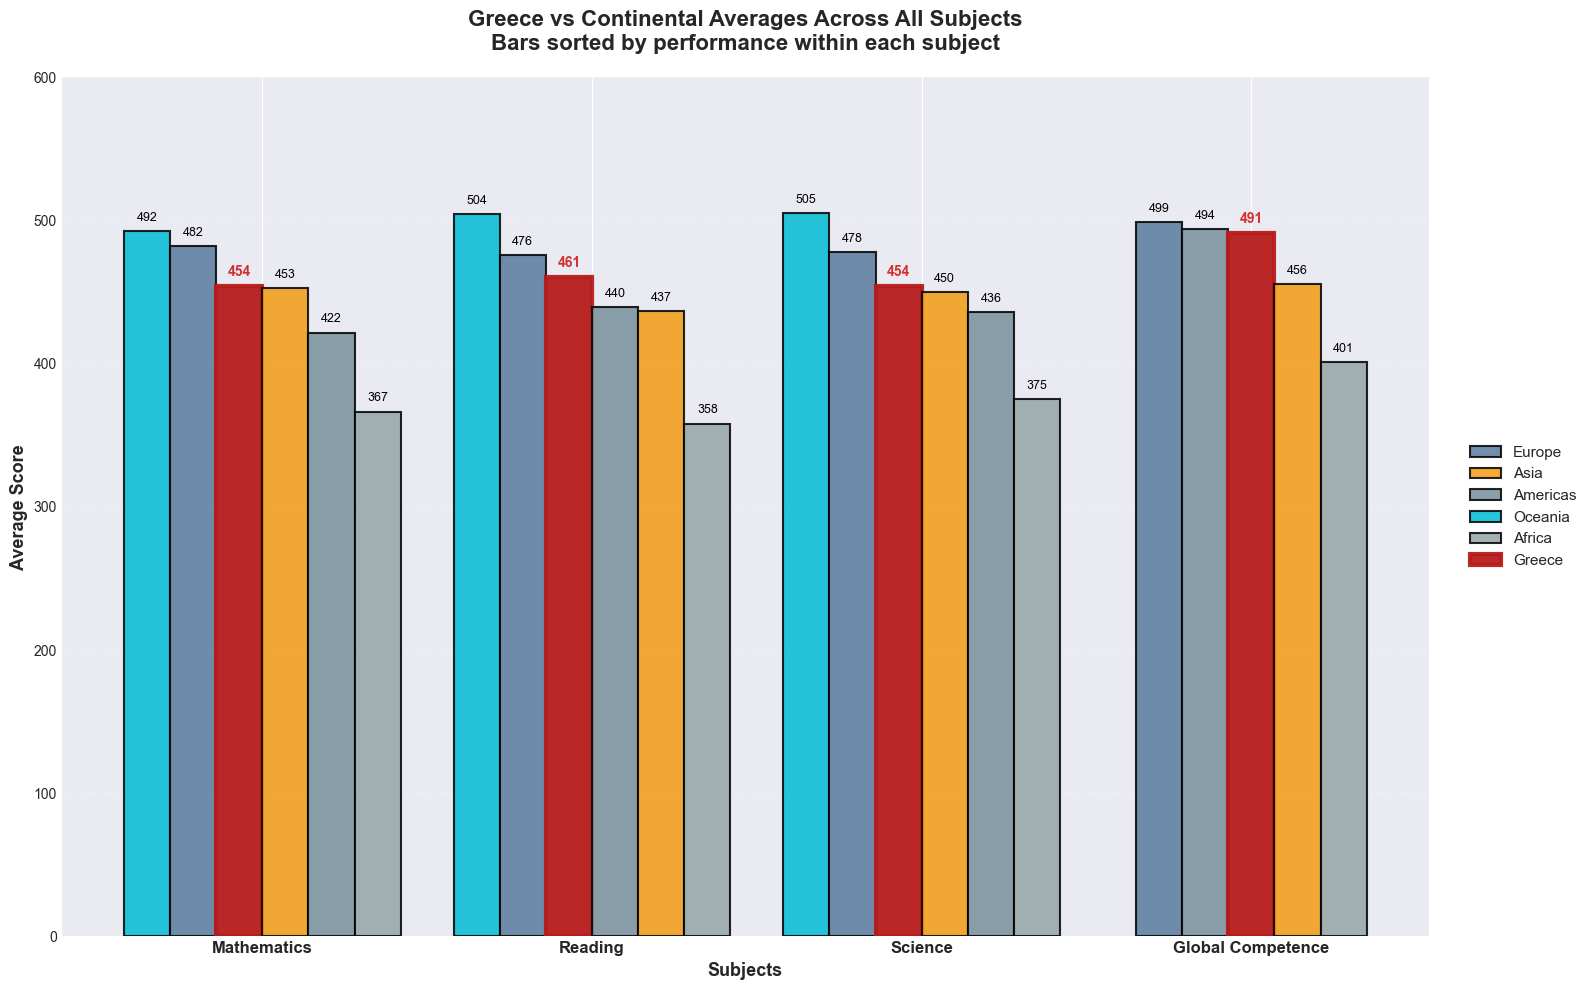

In [21]:
# Define continent mappings

# Add continent column

# Calculate Greece scores
greece_scores = df[df['CNT'] == 'Greece'][SUBJECTS].mean()

# Calculate continental averages
continent_averages = {}
for continent in CONTINENTS:
    continent_df = df[df['Continent'] == continent]
    if len(continent_df) > 0:
        continent_averages[continent] = continent_df[SUBJECTS].mean()

# Create figure
fig, ax = plt.subplots(figsize=(16, 10))

# Bar width and positions
n_subjects = len(SUBJECTS)
bar_width = 0.14
x_base = np.arange(n_subjects)

# Track which groups are plotted for legend
plotted_groups = set()

# For each subject, sort the groups by score
for subj_idx, subject in enumerate(SUBJECTS):
    # Collect scores for this subject (excluding NaN)
    scores_dict = {}
    for continent in CONTINENTS:
        if continent in continent_averages:
            score = continent_averages[continent][subject]
            if not np.isnan(score):
                scores_dict[continent] = score
    
    # Add Greece if not NaN
    if not np.isnan(greece_scores[subject]):
        scores_dict['Greece'] = greece_scores[subject]
    
    # Sort by score (high to low)
    sorted_groups = sorted(scores_dict.items(), key=lambda x: x[1], reverse=True)
    n_groups = len(sorted_groups)
    
    # Plot bars for this subject in sorted order
    for bar_idx, (group, value) in enumerate(sorted_groups):
        x_pos = x_base[subj_idx] + (bar_idx - n_groups/2 + 0.5) * bar_width
        
        is_greece = (group == 'Greece')
        bar = ax.bar(x_pos, value, bar_width,
                    color=CONTINENT_COLORS[group], 
                    alpha=0.95 if is_greece else 0.85,
                    edgecolor='#B71C1C' if is_greece else 'black',
                    linewidth=3 if is_greece else 1.5)
        
        # Track plotted groups for legend
        plotted_groups.add(group)
        
        # Add value labels on top of bars
        fontsize = 10 if is_greece else 9
        fontweight = 'bold' if is_greece else 'normal'
        color = '#D32F2F' if is_greece else 'black'
        ax.text(x_pos, value + 5, f'{value:.0f}',
                ha='center', va='bottom', fontsize=fontsize, 
                fontweight=fontweight, color=color)

# Formatting
ax.set_xlabel('Subjects', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Score', fontsize=13, fontweight='bold')
ax.set_title('Greece vs Continental Averages Across All Subjects\nBars sorted by performance within each subject', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x_base)
ax.set_xticklabels(SUBJECT_NAMES, fontsize=12, fontweight='bold')
ax.set_ylim(0, 600)

# Create custom legend with only plotted groups
legend_elements = []
legend_order = CONTINENTS + ['Greece']
for group in legend_order:
    if group in plotted_groups:
        label = 'Greece' if group == 'Greece' else group
        legend_elements.append(Patch(facecolor=CONTINENT_COLORS[group], 
                                     edgecolor='#B71C1C' if group == 'Greece' else 'black',
                                     linewidth=3 if group == 'Greece' else 1.5,
                                     label=label, alpha=0.95 if group == 'Greece' else 0.85))

ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.02, 0.5),
          fontsize=11, framealpha=0.95, edgecolor='gray')

ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

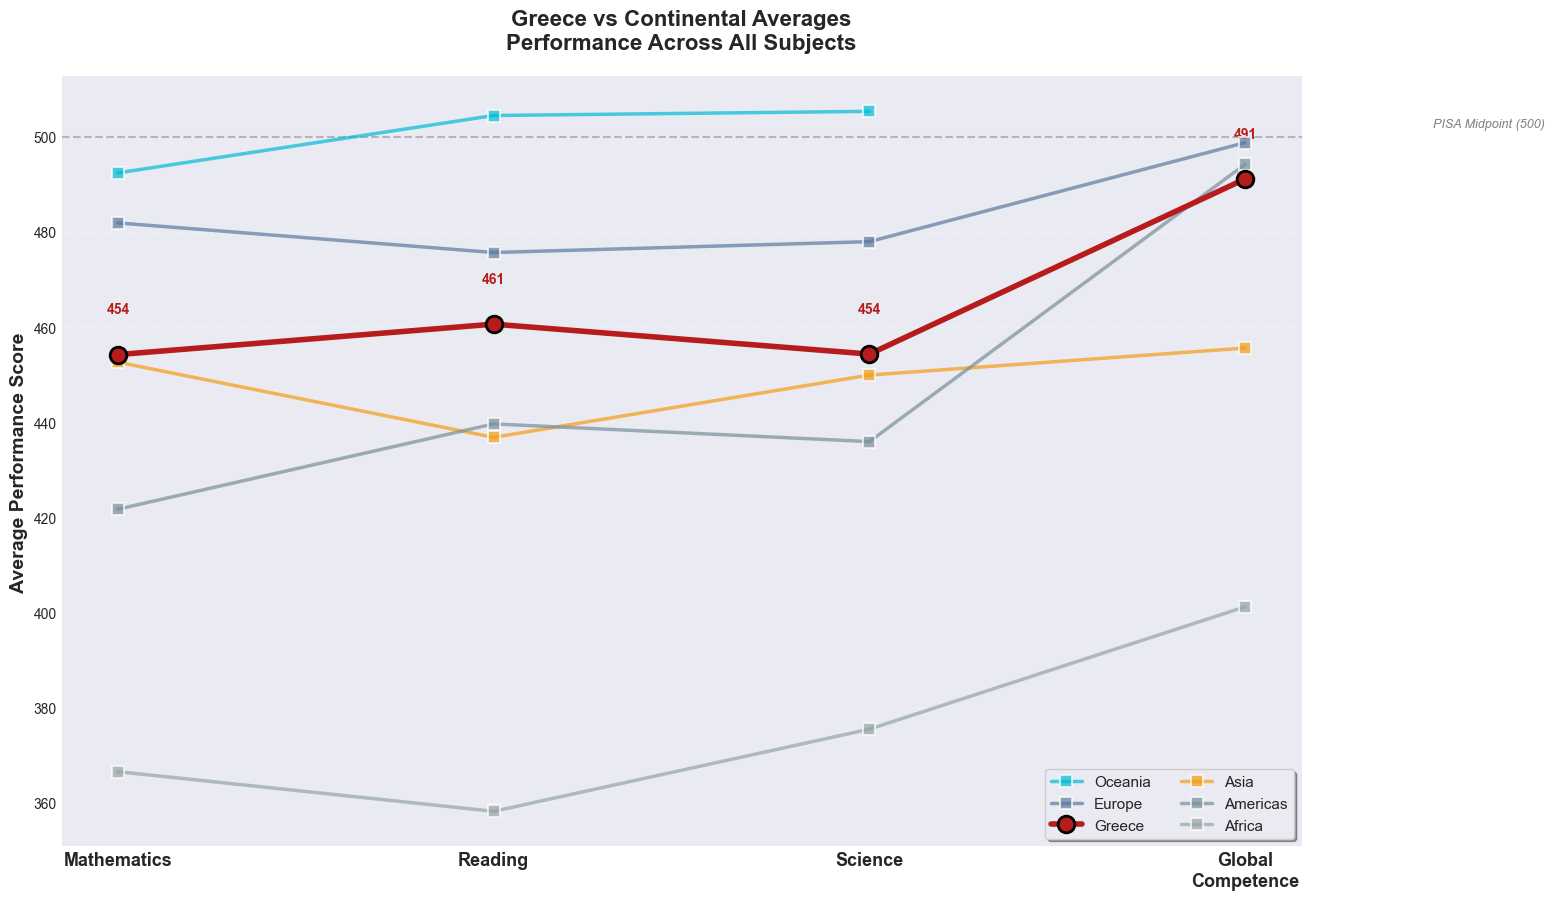

In [22]:
# Calculate continental averages
continent_stats = {}

for continent in ['Europe', 'Asia', 'Americas', 'Oceania', 'Africa']:
    continent_data = df[df['Continent'] == continent]
    if len(continent_data) > 0:
        continent_stats[continent] = {
            'MATH': continent_data['MATH'].mean(),
            'READ': continent_data['READ'].mean(),
            'SCIE': continent_data['SCIE'].mean(),
            'GLCM': continent_data['GLCM'].mean()
        }

# Greece data
if 'Greece' in df['CNT'].unique():
    greece_data = df[df['CNT'] == 'Greece']
    continent_stats['Greece'] = {
        'MATH': greece_data['MATH'].mean(),
        'READ': greece_data['READ'].mean(),
        'SCIE': greece_data['SCIE'].mean(),
        'GLCM': greece_data['GLCM'].mean()
    }

# Create dataframe
stats_df = pd.DataFrame(continent_stats).T
subjects = ['MATH', 'READ', 'SCIE', 'GLCM']
subject_names = ['Mathematics', 'Reading', 'Science', 'Global\nCompetence']

# Create line chart
fig, ax = plt.subplots(figsize=(16, 10))

x = np.arange(len(subjects))

# Plot each continent/Greece
for entity in stats_df.index:
    values = stats_df.loc[entity, subjects].values
    
    if entity == 'Greece':
        # Greece - special styling
        ax.plot(x, values, marker='o', linewidth=4, markersize=12,
               color='#B71C1C', label='Greece', zorder=10,
               markeredgecolor='black', markeredgewidth=2)
        
        # Add value labels for Greece
        for i, (xi, val) in enumerate(zip(x, values)):
            ax.text(xi, val + 8, f'{val:.0f}', ha='center', va='bottom',
                   fontsize=10, fontweight='bold', color='#B71C1C')
    else:
        # Continents - regular styling
        color = CONTINENT_COLORS.get(entity, '#95A5A6')
        ax.plot(x, values, marker='s', linewidth=2.5, markersize=8,
               color=color, label=entity, alpha=0.7, zorder=5,
               markeredgecolor='white', markeredgewidth=1.5)

# Customize
ax.set_xticks(x)
ax.set_xticklabels(subject_names, fontsize=13, fontweight='bold')
ax.set_ylabel('Average Performance Score', fontsize=14, fontweight='bold')
ax.set_title('Greece vs Continental Averages\nPerformance Across All Subjects',
             fontsize=16, fontweight='bold', pad=20)

# Add reference line at 500
ax.axhline(y=500, color='gray', linewidth=1.5, linestyle='--', alpha=0.5)
ax.text(3.5, 502, 'PISA Midpoint (500)', fontsize=9, color='gray', style='italic')

# Legend - sort by average performance
avg_scores = stats_df[subjects].mean(axis=1).sort_values(ascending=False)
sorted_entities = avg_scores.index.tolist()

# Reorder legend handles
handles, labels = ax.get_legend_handles_labels()
label_to_handle = dict(zip(labels, handles))
ordered_handles = [label_to_handle[entity] for entity in sorted_entities if entity in label_to_handle]
ordered_labels = [entity for entity in sorted_entities if entity in label_to_handle]

ax.legend(ordered_handles, ordered_labels, loc='lower right', frameon=True,
         fontsize=11, fancybox=True, shadow=True, ncol=2)

# Grid
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.grid(axis='x', alpha=0.2, linestyle=':')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# # Add insight box
# if 'Greece' in stats_df.index:
#     greece_avg = stats_df.loc['Greece', subjects].mean()
#     global_avg = df[['MATH', 'READ', 'SCIE', 'GLCM']].mean().mean()
#     diff = greece_avg - global_avg
    
#     insight = (f"Greece's overall average: {greece_avg:.1f} points\n"
#               f"Global average: {global_avg:.1f} points\n"
#               f"Difference: {'+' if diff > 0 else ''}{diff:.1f} points")
    
#     ax.text(0.02, 0.98, insight, transform=ax.transAxes, fontsize=10,
#            verticalalignment='top', fontweight='bold', color='#B71C1C',
#            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8,
#                     edgecolor='#B71C1C', linewidth=2))

# Data source
ax.text(0.98, 0.02, 'Data: OECD PISA 2018', transform=ax.transAxes,
        fontsize=9, va='bottom', ha='right', color='#6C757D', style='italic')

# plt.tight_layout()
plt.show()

### Plot Number 8

/var/folders/27/w24km3fs2vl7bm7hlvrwm2l40000gn/T/ipykernel_48131/1227355334.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  country_ed_scores = df.groupby(['CNT', 'ST005Q01TA'])['MATH'].mean().reset_index()


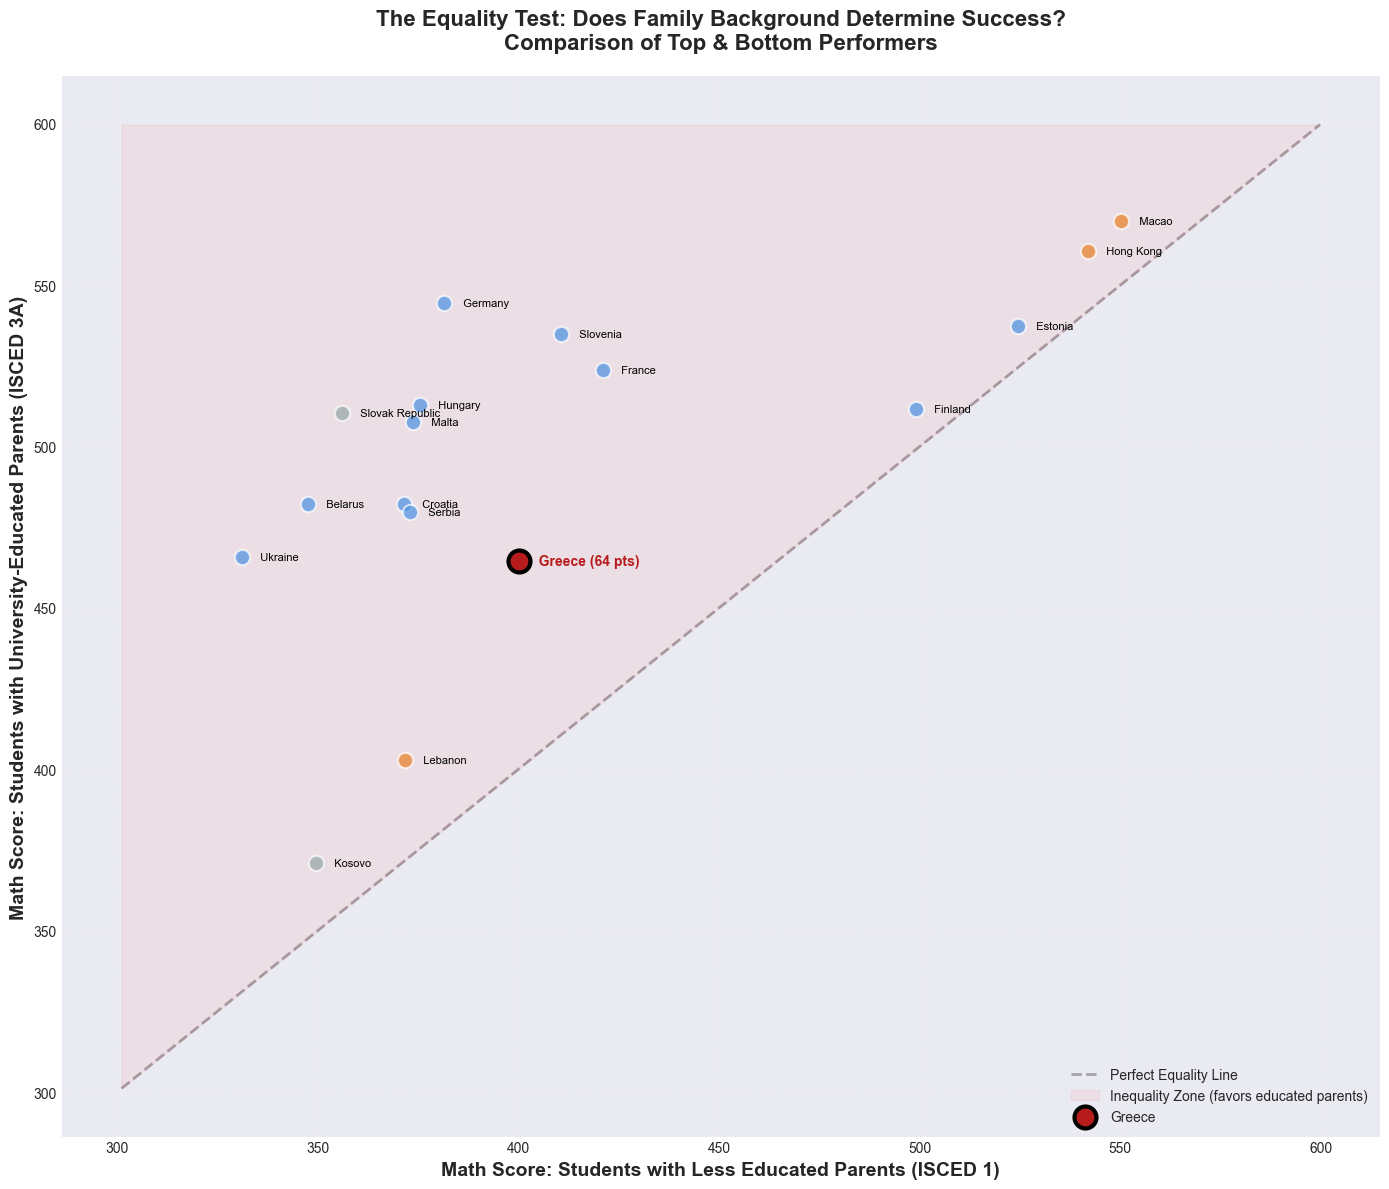

In [23]:
fig, ax = plt.subplots(figsize=(14, 12))

# Calculate mother's education impact for each country
country_ed_scores = df.groupby(['CNT', 'ST005Q01TA'])['MATH'].mean().reset_index()

# Calculate impact (High education - Low education) for each country
impacts = []
for country in df['CNT'].unique():
    country_data = country_ed_scores[country_ed_scores['CNT'] == country]
    
    # Use string values like in original code
    low_ed = country_data[country_data['ST005Q01TA'] == 'ISCED level 1']['MATH'].values
    high_ed = country_data[country_data['ST005Q01TA'] == 'ISCED level 3A']['MATH'].values
    
    if len(low_ed) > 0 and len(high_ed) > 0:
        impacts.append({
            'Country': country,
            'High': high_ed[0],
            'Low': low_ed[0],
            'Gap': high_ed[0] - low_ed[0]
        })

impact_df = pd.DataFrame(impacts).sort_values('Gap', ascending=False)

# Select Top 10, Bottom 10, and Greece
top_10 = impact_df.head(10)
bottom_10 = impact_df.tail(10)
greece_data = impact_df[impact_df['Country'] == 'Greece']

# Combine
selected = pd.concat([top_10, greece_data, bottom_10]).drop_duplicates()

# Get Greece's gap value safely
greece_gap = greece_data['Gap'].values[0] if len(greece_data) > 0 else 0

# Get continent mapping for color coding
continent_colors = {
    'Europe': '#4A90E2',
    'Asia': '#E67E22',
    'North America': '#2ECC71',
    'South America': '#E74C3C',
    'Oceania': '#9B59B6',
    'Africa': '#F39C12'
}

# Plot equality line (45-degree)
max_val = max(selected['High'].max(), selected['Low'].max()) + 30
min_val = min(selected['High'].min(), selected['Low'].min()) - 30
ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.3, linewidth=2, 
        label='Perfect Equality Line', zorder=1)

# Add shading for inequality zones
ax.fill_between([min_val, max_val], [min_val, max_val], max_val, 
                 alpha=0.05, color='red', label='Inequality Zone (favors educated parents)')

# Plot each country with label to the right
for idx, row in selected.iterrows():
    country_name = row['Country']
    
    # Get continent safely
    country_mask = df['CNT'] == country_name
    if country_mask.any():
        continent = df[country_mask]['Continent'].iloc[0]
    else:
        continent = 'Europe'
    
    color = continent_colors.get(continent, '#95A5A6')
    
    # Special styling for Greece - bigger circle
    if country_name == 'Greece':
        ax.scatter(row['Low'], row['High'], s=250, color='#B71C1C', 
                  edgecolors='black', linewidths=3, zorder=5, label='Greece')
        # Label to the right for Greece
        ax.text(row['Low'] + 3, row['High'], f'  Greece ({int(row["Gap"])} pts)', 
               fontsize=10, fontweight='bold', color='#B71C1C',
               va='center', ha='left', zorder=6)
    else:
        ax.scatter(row['Low'], row['High'], s=120, color=color, 
                  edgecolors='white', linewidths=1.5, alpha=0.7, zorder=3)
        # Label to the right for all countries
        ax.text(row['Low'] + 3, row['High'], f'  {country_name}', 
               fontsize=8, color='black', va='center', ha='left', zorder=4)

# Formatting
ax.set_xlabel('Math Score: Students with Less Educated Parents (ISCED 1)', fontsize=14, fontweight='bold')
ax.set_ylabel('Math Score: Students with University-Educated Parents (ISCED 3A)', fontsize=14, fontweight='bold')
ax.set_title('The Equality Test: Does Family Background Determine Success?\nComparison of Top & Bottom Performers', 
            fontsize=16, fontweight='bold', pad=20)

# Add grid
ax.grid(True, alpha=0.2, linestyle=':', linewidth=1)

# Add insight box - handle NaN values
top_gap = int(top_10.iloc[0]['Gap']) if not pd.isna(top_10.iloc[0]['Gap']) else 0
min_gap = int(impact_df['Gap'].min()) if not pd.isna(impact_df['Gap'].min()) else 0

# Legend
handles, labels_legend = ax.get_legend_handles_labels()
# Remove duplicate labels
by_label = dict(zip(labels_legend, handles))
ax.legend(by_label.values(), by_label.keys(), loc='lower right', fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.show()

### Plot Number 9

/var/folders/27/w24km3fs2vl7bm7hlvrwm2l40000gn/T/ipykernel_48131/4254072987.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  subject_country_means = df.groupby('CNT')[col].mean().dropna().sort_values(ascending=False)


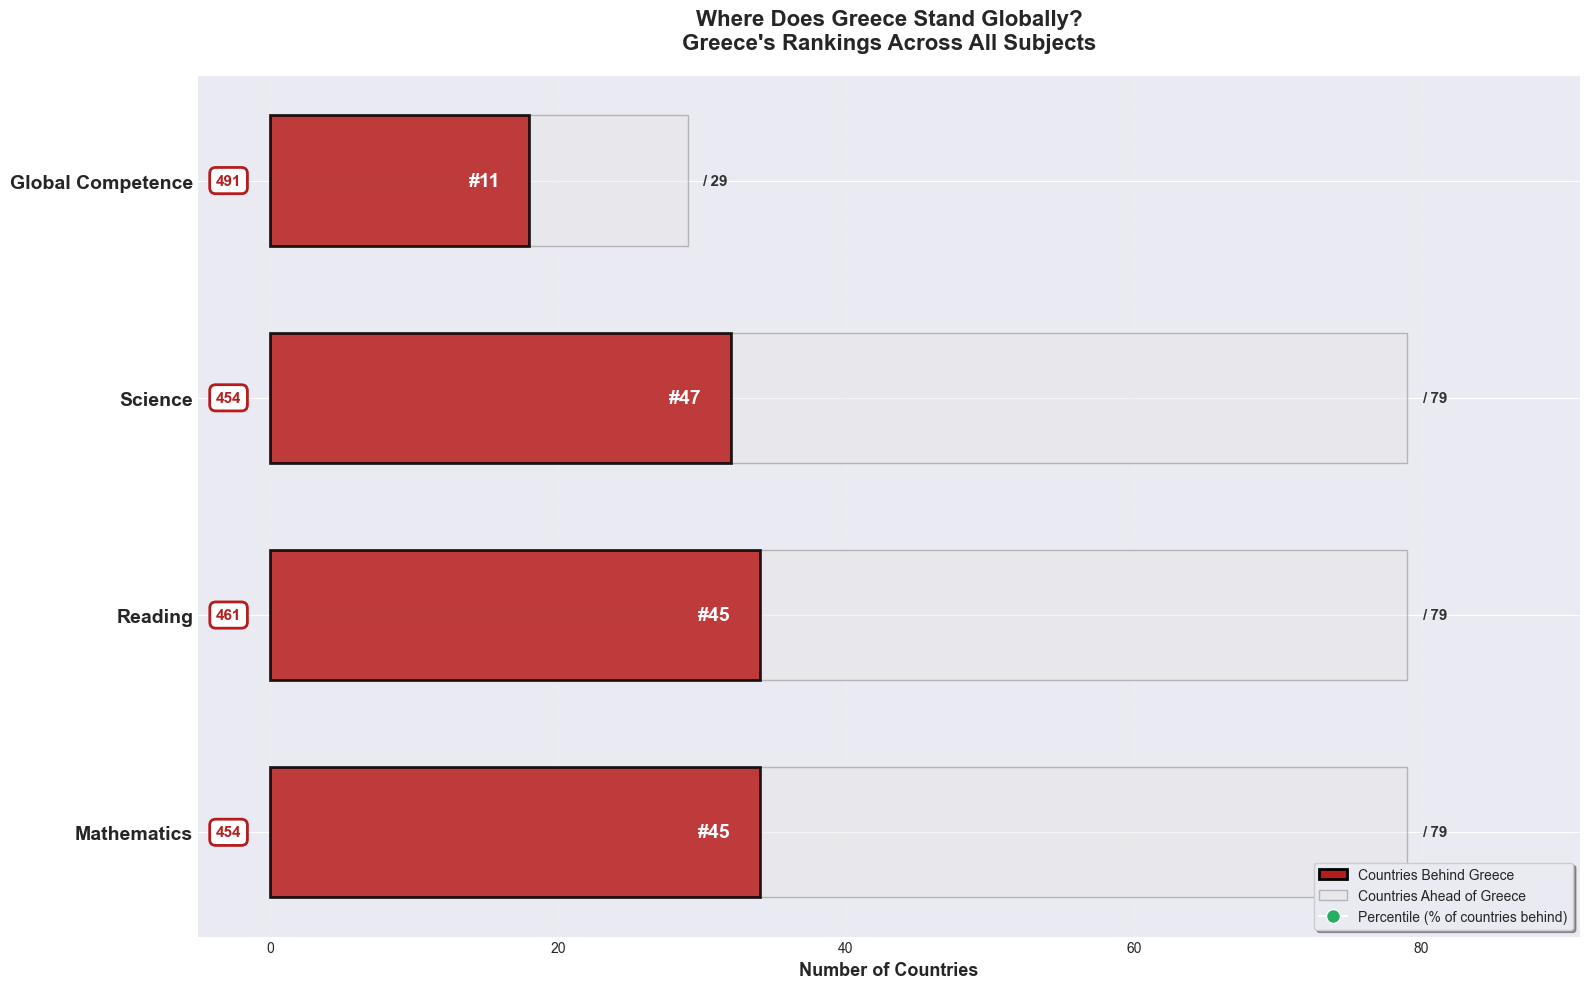

In [24]:
# Calculate country averages for each subject
subjects_data = {
    'Mathematics': 'MATH',
    'Reading': 'READ',
    'Science': 'SCIE',
    'Global Competence': 'GLCM'
}

greece_rankings = {}
total_countries = {}

for subject, col in subjects_data.items():
    # Calculate country means
    subject_country_means = df.groupby('CNT')[col].mean().dropna().sort_values(ascending=False)
    
    # Get Greece's rank
    if 'Greece' in subject_country_means.index:
        greece_rank = list(subject_country_means.index).index('Greece') + 1
        greece_score = subject_country_means['Greece']
        total = len(subject_country_means)
        
        greece_rankings[subject] = {
            'rank': greece_rank,
            'total': total,
            'score': greece_score,
            'percentile': (total - greece_rank) / total * 100  # Higher is better
        }
        total_countries[subject] = total

# Create visualization
fig, ax = plt.subplots(figsize=(16, 10))

subjects = list(greece_rankings.keys())
y_pos = np.arange(len(subjects))

# Plot for each subject
for i, subject in enumerate(subjects):
    data = greece_rankings[subject]
    rank = data['rank']
    total = data['total']
    score = data['score']
    percentile = data['percentile']
    
    # Background bar (total countries)
    ax.barh(i, total, height=0.6, color='#E8E8E8', alpha=0.5, 
            edgecolor='gray', linewidth=1, zorder=1)
    
    # Greece's position bar (countries behind Greece)
    countries_behind = total - rank
    ax.barh(i, countries_behind, height=0.6, color='#B71C1C', alpha=0.85,
            edgecolor='black', linewidth=2, zorder=3)
    
    # Add rank text (LEFT side - inside filled portion)
    rank_text = f"#{rank}"
    ax.text(countries_behind - 2, i, rank_text, 
           ha='right', va='center', fontsize=14, fontweight='bold',
           color='white', zorder=4)
    
    # Add "out of X" text (RIGHT side)
    ax.text(total + 1, i, f'/ {total}', 
           ha='left', va='center', fontsize=11, color='#333333',
           fontweight='bold')
    
    # Add score on the left
    ax.text(-2, i, f'{score:.0f}', ha='right', va='center',
           fontsize=11, fontweight='bold', color='#B71C1C',
           bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                    edgecolor='#B71C1C', linewidth=2))
    
#     # Add percentile badge on the right
#     percentile_color = '#27AE60' if percentile > 50 else '#E74C3C'
#     ax.text(total + 8, i, f'{percentile:.0f}%',
#            ha='left', va='center', fontsize=10, fontweight='bold',
#            color='white',
#            bbox=dict(boxstyle='round,pad=0.3', facecolor=percentile_color,
#                     edgecolor='white', linewidth=1.5))

# Customize
ax.set_yticks(y_pos)
ax.set_yticklabels(subjects, fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Countries', fontsize=13, fontweight='bold')
ax.set_title('Where Does Greece Stand Globally?\nGreece\'s Rankings Across All Subjects', 
             fontsize=16, fontweight='bold', pad=20)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Set x limits with padding
max_total = max([data['total'] for data in greece_rankings.values()])
ax.set_xlim(-5, max_total + 12)

# Add grid
ax.grid(axis='x', alpha=0.2, linestyle='--', zorder=0)
ax.set_axisbelow(True)

# Add legend/explanation
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Patch(facecolor='#B71C1C', edgecolor='black', linewidth=2, 
          label='Countries Behind Greece'),
    Patch(facecolor='#E8E8E8', edgecolor='gray', linewidth=1, alpha=0.5,
          label='Countries Ahead of Greece'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#27AE60',
           markersize=10, label='Percentile (% of countries behind)')
]
ax.legend(handles=legend_elements, loc='lower right', frameon=True,
         fontsize=10, fancybox=True, shadow=True)

# Data source
ax.text(0.98, 0.02, 'Data: OECD PISA 2018', transform=ax.transAxes,
        fontsize=9, va='bottom', ha='right', color='#6C757D', style='italic')

plt.tight_layout()
plt.show()

### Plot Number 10

/var/folders/27/w24km3fs2vl7bm7hlvrwm2l40000gn/T/ipykernel_48131/520611412.py:189: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniconda/base/envs/data_visualisation/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


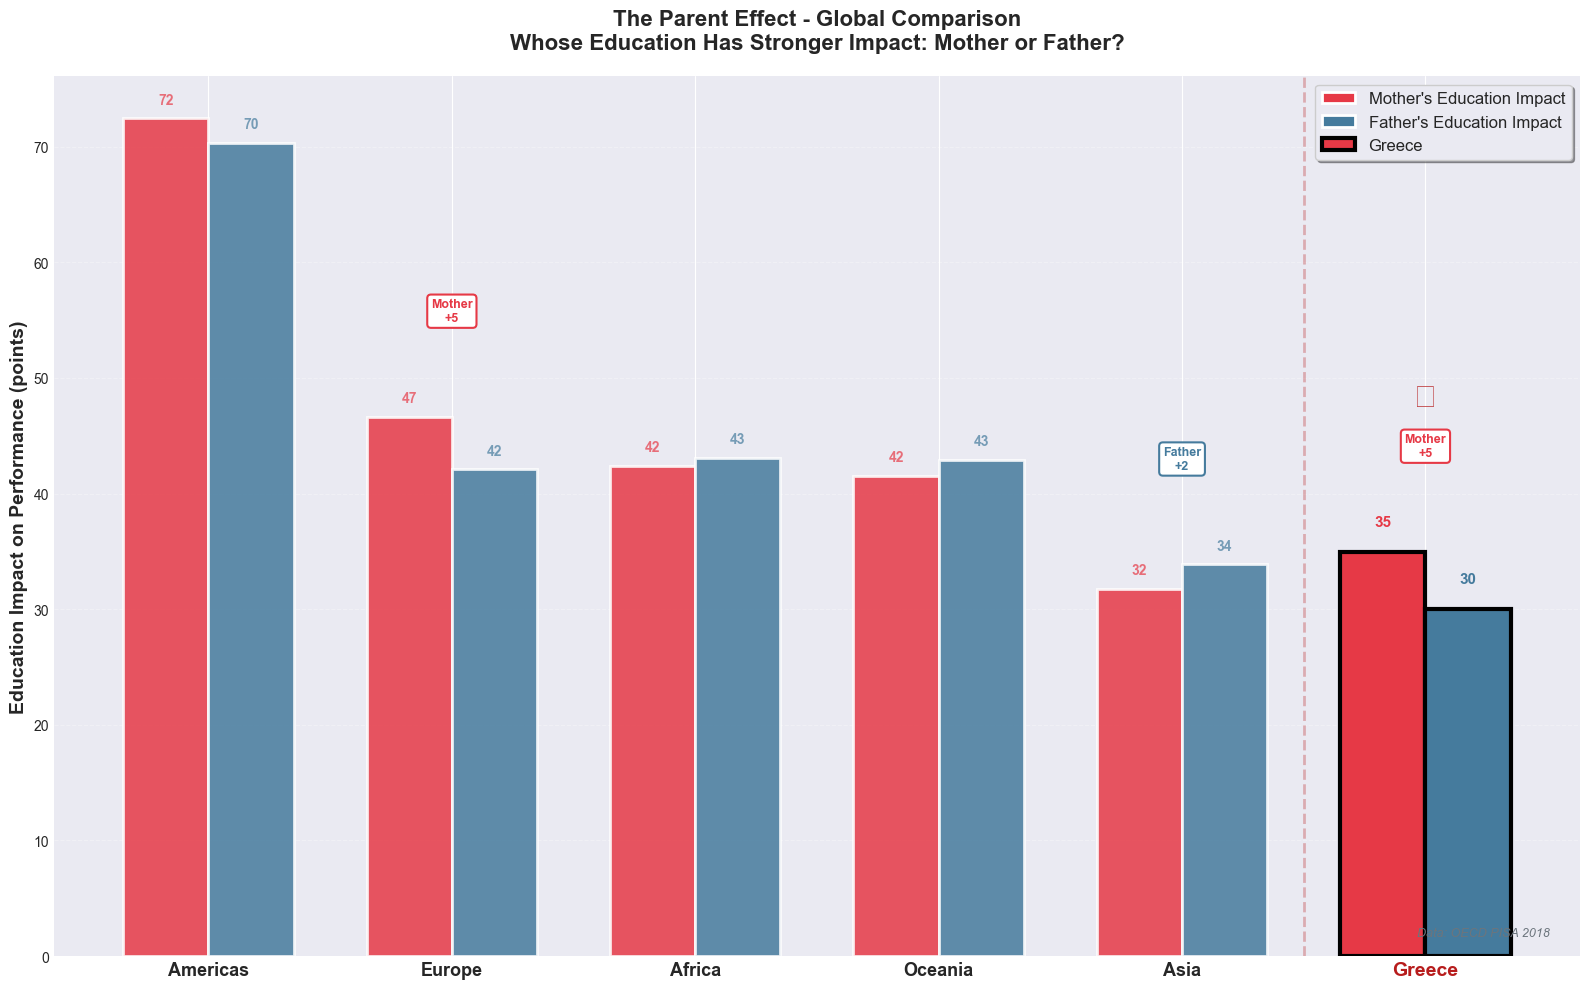

In [25]:
def calculate_education_gap(df_subset, parent_column, subject_cols):
    """Calculate performance gap between high and low parental education"""
    valid_ed = df_subset[df_subset[parent_column].notna() & 
                         df_subset[parent_column].isin(['ISCED level 1', 'ISCED level 2', 
                                                         'ISCED level 3A', 'ISCED level 3B, 3C'])].copy()
    
    if len(valid_ed) < 50:
        return np.nan
    
    # High education = ISCED 3A (university)
    valid_ed['high_ed'] = valid_ed[parent_column] == 'ISCED level 3A'
    
    if valid_ed['high_ed'].sum() < 10 or (~valid_ed['high_ed']).sum() < 10:
        return np.nan
    
    # Average score for students with highly educated parents
    high_ed_scores = valid_ed[valid_ed['high_ed']][subject_cols].mean().mean()
    
    # Average score for students with less educated parents
    low_ed_scores = valid_ed[~valid_ed['high_ed']][subject_cols].mean().mean()
    
    # Impact = difference
    return high_ed_scores - low_ed_scores

subject_cols = ['MATH', 'READ', 'SCIE']

# Calculate impact for each continent
continent_impacts = {}

for continent in ['Europe', 'Asia', 'Americas', 'Oceania', 'Africa']:
    # Get all countries from this continent
    continent_data = df[df['Continent'] == continent]
    
    if len(continent_data) > 0:
        mother_impact = calculate_education_gap(continent_data, 'ST005Q01TA', subject_cols)
        father_impact = calculate_education_gap(continent_data, 'ST007Q01TA', subject_cols)
        
        if not np.isnan(mother_impact) and not np.isnan(father_impact):
            continent_impacts[continent] = {
                'Mother': mother_impact,
                'Father': father_impact
            }

# Calculate for Greece separately
if 'Greece' in df['CNT'].unique():
    greece_data = df[df['CNT'] == 'Greece']
    greece_mother = calculate_education_gap(greece_data, 'ST005Q01TA', subject_cols)
    greece_father = calculate_education_gap(greece_data, 'ST007Q01TA', subject_cols)
    
    if not np.isnan(greece_mother) and not np.isnan(greece_father):
        continent_impacts['Greece'] = {
            'Mother': greece_mother,
            'Father': greece_father
        }

# Prepare data for plotting
entities = []
mother_values = []
father_values = []

# First add continents (sorted by total impact)
continent_data = {k: v for k, v in continent_impacts.items() if k != 'Greece'}
sorted_continents = sorted(continent_data.items(), 
                           key=lambda x: x[1]['Mother'] + x[1]['Father'], 
                           reverse=True)

for continent, values in sorted_continents:
    entities.append(continent)
    mother_values.append(values['Mother'])
    father_values.append(values['Father'])

# Add Greece at the end (after continents)
if 'Greece' in continent_impacts:
    entities.append('Greece')
    mother_values.append(continent_impacts['Greece']['Mother'])
    father_values.append(continent_impacts['Greece']['Father'])

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(16, 10))

x = np.arange(len(entities))
width = 0.35

# Mother bars
mother_bars = ax.bar(x - width/2, mother_values, width,
                     label='Mother\'s Education Impact',
                     color='#E63946', alpha=0.85, edgecolor='white', linewidth=2)

# Father bars
father_bars = ax.bar(x + width/2, father_values, width,
                     label='Father\'s Education Impact',
                     color='#457B9D', alpha=0.85, edgecolor='white', linewidth=2)

# Highlight Greece with different styling
if 'Greece' in entities:
    greece_idx = entities.index('Greece')
    
    # Re-style Greece bars
    mother_bars[greece_idx].set_alpha(1.0)
    mother_bars[greece_idx].set_edgecolor('black')
    mother_bars[greece_idx].set_linewidth(3)
    
    father_bars[greece_idx].set_alpha(1.0)
    father_bars[greece_idx].set_edgecolor('black')
    father_bars[greece_idx].set_linewidth(3)
    
    # Add values on Greece bars
    ax.text(greece_idx - width/2, mother_values[greece_idx] + 2,
           f'{mother_values[greece_idx]:.0f}',
           ha='center', va='bottom', fontsize=11, fontweight='bold', color='#E63946')
    ax.text(greece_idx + width/2, father_values[greece_idx] + 2,
           f'{father_values[greece_idx]:.0f}',
           ha='center', va='bottom', fontsize=11, fontweight='bold', color='#457B9D')
    
    # Add star marker
    ax.text(greece_idx, max(mother_values[greece_idx], father_values[greece_idx]) + 12,
           '★', ha='center', va='bottom', fontsize=24, color='#B71C1C')

# Add values on top of all other bars
for i, (m_bar, f_bar, m_val, f_val) in enumerate(zip(mother_bars, father_bars, 
                                                       mother_values, father_values)):
    if entities[i] != 'Greece':  # Skip Greece, already done
        ax.text(m_bar.get_x() + m_bar.get_width()/2., m_val + 1,
               f'{m_val:.0f}', ha='center', va='bottom', 
               fontsize=10, fontweight='bold', color='#E63946', alpha=0.7)
        ax.text(f_bar.get_x() + f_bar.get_width()/2., f_val + 1,
               f'{f_val:.0f}', ha='center', va='bottom',
               fontsize=10, fontweight='bold', color='#457B9D', alpha=0.7)

# Add difference indicators
for i, (entity, m_val, f_val) in enumerate(zip(entities, mother_values, father_values)):
    diff = f_val - m_val
    
    if abs(diff) > 2:  # Only show if meaningful
        y_pos = max(m_val, f_val) + 8
        
        if diff > 0:
            color = '#457B9D'
            text = f'Father\n+{diff:.0f}'
        else:
            color = '#E63946'
            text = f'Mother\n+{abs(diff):.0f}'
        
        ax.annotate(text, xy=(i, y_pos), ha='center', va='bottom',
                   fontsize=9, fontweight='bold', color=color,
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                            edgecolor=color, linewidth=1.5))

# Customize
ax.set_xticks(x)
ax.set_xticklabels(entities, fontsize=13, fontweight='bold')

# Bold Greece label
if 'Greece' in entities:
    labels = ax.get_xticklabels()
    labels[entities.index('Greece')].set_color('#B71C1C')
    labels[entities.index('Greece')].set_fontsize(14)

ax.set_ylabel('Education Impact on Performance (points)', fontsize=14, fontweight='bold')
ax.set_title('The Parent Effect - Global Comparison\nWhose Education Has Stronger Impact: Mother or Father?', 
             fontsize=16, fontweight='bold', pad=20)

# Add separator line before Greece
if 'Greece' in entities:
    greece_idx = entities.index('Greece')
    ax.axvline(x=greece_idx - 0.5, color='#B71C1C', linewidth=2, 
              alpha=0.3, linestyle='--')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E63946', edgecolor='white', linewidth=2, label='Mother\'s Education Impact'),
    Patch(facecolor='#457B9D', edgecolor='white', linewidth=2, label='Father\'s Education Impact'),
    Patch(facecolor='#E63946', edgecolor='black', linewidth=3, label='Greece', alpha=1.0)
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True,
         fontsize=12, fancybox=True, shadow=True)

# Grid
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Data source
ax.text(0.98, 0.02, 'Data: OECD PISA 2018', transform=ax.transAxes,
        fontsize=9, va='bottom', ha='right', color='#6C757D', style='italic')

plt.tight_layout()
plt.show()

### Plot Number 11

/var/folders/27/w24km3fs2vl7bm7hlvrwm2l40000gn/T/ipykernel_48131/755499515.py:163: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniconda/base/envs/data_visualisation/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


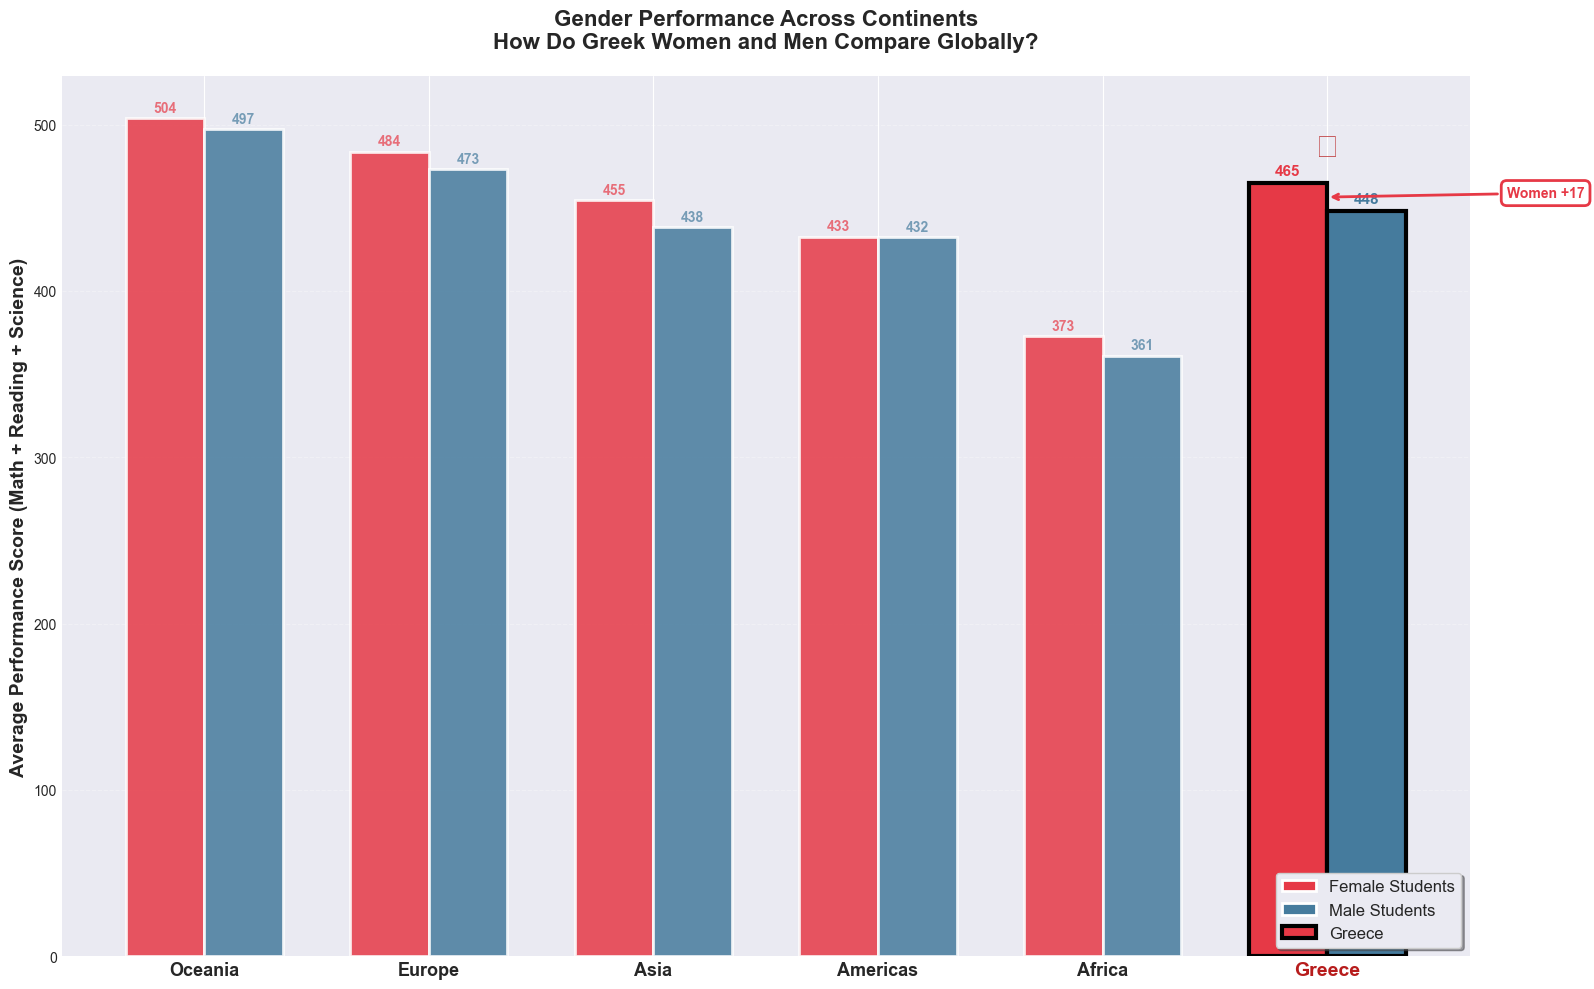

In [26]:
# PLOT 11: Gender Performance Across Continents
# How do Greek women and men compare to their peers globally?

# Calculate average scores by gender for each continent
gender_continent_stats = {}

for continent in ['Europe', 'Asia', 'Americas', 'Oceania', 'Africa']:
    continent_data = df[df['Continent'] == continent]
    
    if len(continent_data) > 0:
        # Female average
        female_data = continent_data[continent_data['ST004D01T'] == 'Female']
        female_avg = female_data[['MATH', 'READ', 'SCIE']].mean().mean()
        
        # Male average
        male_data = continent_data[continent_data['ST004D01T'] == 'Male']
        male_avg = male_data[['MATH', 'READ', 'SCIE']].mean().mean()
        
        if not np.isnan(female_avg) and not np.isnan(male_avg):
            gender_continent_stats[continent] = {
                'Female': female_avg,
                'Male': male_avg
            }

# Calculate for Greece separately
if 'Greece' in df['CNT'].unique():
    greece_data = df[df['CNT'] == 'Greece']
    
    greek_female = greece_data[greece_data['ST004D01T'] == 'Female'][['MATH', 'READ', 'SCIE']].mean().mean()
    greek_male = greece_data[greece_data['ST004D01T'] == 'Male'][['MATH', 'READ', 'SCIE']].mean().mean()
    
    if not np.isnan(greek_female) and not np.isnan(greek_male):
        gender_continent_stats['Greece'] = {
            'Female': greek_female,
            'Male': greek_male
        }

# Prepare data for plotting
entities = []
female_values = []
male_values = []

# Sort continents by overall average
continent_data = {k: v for k, v in gender_continent_stats.items() if k != 'Greece'}
sorted_continents = sorted(continent_data.items(),
                           key=lambda x: (x[1]['Female'] + x[1]['Male']) / 2,
                           reverse=True)

for continent, values in sorted_continents:
    entities.append(continent)
    female_values.append(values['Female'])
    male_values.append(values['Male'])

# Add Greece at the end
if 'Greece' in gender_continent_stats:
    entities.append('Greece')
    female_values.append(gender_continent_stats['Greece']['Female'])
    male_values.append(gender_continent_stats['Greece']['Male'])

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(16, 10))

x = np.arange(len(entities))
width = 0.35

# Female bars
female_bars = ax.bar(x - width/2, female_values, width,
                     label='Female Students',
                     color='#E63946', alpha=0.85, edgecolor='white', linewidth=2)

# Male bars
male_bars = ax.bar(x + width/2, male_values, width,
                   label='Male Students',
                   color='#457B9D', alpha=0.85, edgecolor='white', linewidth=2)

# Highlight Greece
if 'Greece' in entities:
    greece_idx = entities.index('Greece')
    
    # Re-style Greece bars
    female_bars[greece_idx].set_alpha(1.0)
    female_bars[greece_idx].set_edgecolor('black')
    female_bars[greece_idx].set_linewidth(3)
    
    male_bars[greece_idx].set_alpha(1.0)
    male_bars[greece_idx].set_edgecolor('black')
    male_bars[greece_idx].set_linewidth(3)
    
    # Add values on Greece bars
    ax.text(greece_idx - width/2, female_values[greece_idx] + 3,
           f'{female_values[greece_idx]:.0f}',
           ha='center', va='bottom', fontsize=11, fontweight='bold', color='#E63946')
    ax.text(greece_idx + width/2, male_values[greece_idx] + 3,
           f'{male_values[greece_idx]:.0f}',
           ha='center', va='bottom', fontsize=11, fontweight='bold', color='#457B9D')
    
    # Add star
    ax.text(greece_idx, max(female_values[greece_idx], male_values[greece_idx]) + 12,
           '★', ha='center', va='bottom', fontsize=24, color='#B71C1C')
    
    # Add gender gap annotation for Greece
    greece_gap = male_values[greece_idx] - female_values[greece_idx]
    if abs(greece_gap) > 1:
        gap_y = (female_values[greece_idx] + male_values[greece_idx]) / 2
        if greece_gap > 0:
            gap_text = f'Men +{greece_gap:.0f}'
            gap_color = '#457B9D'
        else:
            gap_text = f'Women +{abs(greece_gap):.0f}'
            gap_color = '#E63946'
        
        ax.annotate(gap_text, xy=(greece_idx, gap_y), xytext=(greece_idx + 0.8, gap_y),
                   fontsize=10, fontweight='bold', color=gap_color,
                   arrowprops=dict(arrowstyle='->', color=gap_color, lw=2),
                   bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                            edgecolor=gap_color, linewidth=2))

# Add values on continent bars
for i, (f_bar, m_bar, f_val, m_val) in enumerate(zip(female_bars, male_bars,
                                                       female_values, male_values)):
    if entities[i] != 'Greece':
        ax.text(f_bar.get_x() + f_bar.get_width()/2., f_val + 2,
               f'{f_val:.0f}', ha='center', va='bottom',
               fontsize=10, fontweight='bold', color='#E63946', alpha=0.7)
        ax.text(m_bar.get_x() + m_bar.get_width()/2., m_val + 2,
               f'{m_val:.0f}', ha='center', va='bottom',
               fontsize=10, fontweight='bold', color='#457B9D', alpha=0.7)

# Customize
ax.set_xticks(x)
ax.set_xticklabels(entities, fontsize=13, fontweight='bold')

# Bold Greece label
if 'Greece' in entities:
    labels = ax.get_xticklabels()
    labels[entities.index('Greece')].set_color('#B71C1C')
    labels[entities.index('Greece')].set_fontsize(14)

ax.set_ylabel('Average Performance Score (Math + Reading + Science)', fontsize=14, fontweight='bold')
ax.set_title('Gender Performance Across Continents\nHow Do Greek Women and Men Compare Globally?',
             fontsize=16, fontweight='bold', pad=20)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E63946', edgecolor='white', linewidth=2, label='Female Students'),
    Patch(facecolor='#457B9D', edgecolor='white', linewidth=2, label='Male Students'),
    Patch(facecolor='#E63946', edgecolor='black', linewidth=3, label='Greece', alpha=1.0)
]
ax.legend(handles=legend_elements, loc='lower right', frameon=True,
         fontsize=12, fancybox=True, shadow=True)

# Grid
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Data source
ax.text(0.98, 0.02, 'Data: OECD PISA 2018', transform=ax.transAxes,
        fontsize=9, va='bottom', ha='right', color='#6C757D', style='italic')

plt.tight_layout()
plt.show()

## TODO: Use Py Shiny for interactive plots?

In [27]:
# !pip install ipywidgets

In [28]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
country_means_clean = country_means.dropna(subset=['MATH', 'READ', 'SCIE', 'GLCM'])
available_countries = sorted(country_means_clean.index.tolist())

def create_radar_chart(country):
    """Create radar chart for selected country"""
    
    # Get country data
    if country not in country_means_clean.index:
        print(f"Data not available for {country}")
        return
    
    country_data = country_means_clean.loc[country]
    
    # Subjects and values
    subjects = ['Mathematics', 'Reading', 'Science', 'Global Competence']
    values = [
        country_data['MATH'],
        country_data['READ'],
        country_data['SCIE'],
        country_data['GLCM']
    ]
    
    # Global averages for comparison
    global_avg = [
        country_means_clean['MATH'].mean(),
        country_means_clean['READ'].mean(),
        country_means_clean['SCIE'].mean(),
        country_means_clean['GLCM'].mean()
    ]
    
    # Number of variables
    num_vars = len(subjects)
    
    # Compute angle for each axis
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    values += values[:1]  # Complete the circle
    global_avg += global_avg[:1]
    angles += angles[:1]
    
    # Create plot
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
    
    # Plot country data
    ax.plot(angles, values, 'o-', linewidth=3, label=country, color='#E63946')
    ax.fill(angles, values, alpha=0.25, color='#E63946')
    
    # Plot global average
    ax.plot(angles, global_avg, 'o--', linewidth=2, label='Global Average', 
            color='#457B9D', alpha=0.7)
    ax.fill(angles, global_avg, alpha=0.1, color='#457B9D')
    
    # Fix axis to go in the right order
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    
    # Draw axis lines for each angle and label
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(subjects, size=12, fontweight='bold')
    
    # Set y-axis limits
    ax.set_ylim(300, 600)
    ax.set_yticks([350, 400, 450, 500, 550])
    ax.set_yticklabels(['350', '400', '450', '500', '550'], size=10)
    
    # Add legend
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
    
    # Title
    plt.title(f'{country}: Performance Across Subjects\nPISA 2018',
              size=16, fontweight='bold', color='#1A237E', pad=20)
    
    # Grid
    ax.grid(True, linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    plt.show()

# Create dropdown widget
country_dropdown = widgets.Dropdown(
    options=available_countries,
    value='Greece',  # Default value
    description='Country:',
    style={'description_width': 'initial'}
)

# Create interactive output
interactive_plot = widgets.interactive(create_radar_chart, country=country_dropdown)

display(interactive_plot)


interactive(children=(Dropdown(description='Country:', index=8, options=('Albania', 'Brunei Darussalam', 'Cana…

In [29]:
# ============================================================================
# INTERACTIVE PLOT 2: Gender Performance by Continent
# Select gender to see performance comparison across continents
# ============================================================================

import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np

def create_gender_continent_chart(gender):
    """Create bar chart showing selected gender's performance by continent"""
    
    # Calculate average scores by gender for each continent
    continent_scores = {}
    
    for continent in ['Europe', 'Asia', 'Americas', 'Oceania', 'Africa']:
        continent_data = df[df['Continent'] == continent]
        
        if len(continent_data) > 0:
            gender_data = continent_data[continent_data['ST004D01T'] == gender]
            
            if len(gender_data) > 0:
                # Average across Math, Reading, Science
                avg_score = gender_data[['MATH', 'READ', 'SCIE']].mean().mean()
                continent_scores[continent] = avg_score
    
    # Sort by score
    sorted_continents = sorted(continent_scores.items(), key=lambda x: x[1], reverse=True)
    continents = [x[0] for x in sorted_continents]
    scores = [x[1] for x in sorted_continents]
    
    # Create bar chart
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Colors
    if gender == 'Female':
        color = '#E63946'
        label_color = '#B71C1C'
    else:
        color = '#457B9D'
        label_color = '#1A5490'
    
    bars = ax.barh(continents, scores, color=color, alpha=0.85,
                   edgecolor='white', linewidth=2)
    
    # Add value labels
    for i, (bar, score) in enumerate(zip(bars, scores)):
        ax.text(score + 5, i, f'{score:.1f}', 
                va='center', fontsize=11, fontweight='bold', color=label_color)
    
    # Styling
    ax.set_xlabel('Average Performance Score (Math + Reading + Science)', 
                  fontsize=13, fontweight='bold')
    ax.set_title(f'{gender} Students: Performance by Continent\nPISA 2018',
                 fontsize=16, fontweight='bold', color='#1A237E', pad=20)
    
    # Add global average line
    global_avg = df[df['ST004D01T'] == gender][['MATH', 'READ', 'SCIE']].mean().mean()
    ax.axvline(x=global_avg, color='#2E86AB', linewidth=2.5, 
               linestyle='--', alpha=0.7, label=f'Global Average ({global_avg:.1f})')
    
    ax.legend(loc='lower right', fontsize=11)
    
    # Grid
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    # Remove spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# Create radio buttons widget
gender_radio = widgets.RadioButtons(
    options=['Female', 'Male'],
    value='Female',  # Default value
    description='Gender:',
    style={'description_width': 'initial'}
)

# Create interactive output
interactive_plot2 = widgets.interactive(create_gender_continent_chart, gender=gender_radio)

display(interactive_plot2)


interactive(children=(RadioButtons(description='Gender:', options=('Female', 'Male'), style=DescriptionStyle(d…